In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pickle

from neurolib.models.wc import WCModel
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics
import pandas as pd
import seaborn as sns


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

import matplotlib as mpl

fig_width = 3. * 15 / 2.54  # Convert cm to inches
fig_width_landscape = 3. * 23.2 / 2.54  # Convert cm to inches

label_size= 30
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 2
plt.rcParams['text.usetex'] = True

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Modern",
    'figure.figsize': [fig_width, 0.35*fig_width],  # Fit A4 with margins
})
colmap = mpl.cm.get_cmap('tab10')


def ploterrorrange(a, x_axis, linfit, linfitstd):
    xpos = np.linspace(0., x_axis[-1], 100)
    a.fill_between(xpos, linfit[1]-linfitstd[1] + xpos*(linfit[0]-linfitstd[0]), linfit[1] + xpos*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xpos, linfit[1] + xpos*linfit[0], linfit[1]+linfitstd[1] + xpos*(linfit[0]+linfitstd[0]), color="red", alpha=0.3 )
    xneg = np.linspace(x_axis[0], -1e-3, 100, )
    a.fill_between(xneg, linfit[1]-linfitstd[1] + xneg*(linfit[0]+linfitstd[0]), linfit[1] + xneg*linfit[0], color="red", alpha=0.3 )
    a.fill_between(xneg, linfit[1] + xneg*linfit[0], linfit[1]+linfitstd[1] + xneg*(linfit[0]-linfitstd[0]), color="red", alpha=0.3 )

def get_sphere_coords(x,y,z):
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z/r)
    phi = np.sign(y)*np.arccos(x/np.sqrt(x**2 + y**2))
    return r, theta, phi

def norm_time(state, time):
    state_norm = np.zeros((len(time)))
   
    ratio = len(state[:])/len(time)

    if ratio == 1:
        state_norm = state.copy()
    elif ratio > 1:
        skip_ind = 1./(ratio-1.)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            while t > mult_r*skip_ind:
                mult_r += 1
                t_count += 1
    else:
        repeat_ind = 1./(1.-ratio)
        t_count = 0
        mult_r = 0
        for t in range(len(time)):
            state_norm[t] = state[t_count]
            t_count += 1
            while t > mult_r*repeat_ind:
                mult_r += 1
                t_count -= 1

    return state_norm

/tmp/ipykernel_557033/681474317.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')


In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()

/tmp/ipykernel_557033/854259224.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  coord_data = pd.read_csv(os.path.join(os.getcwd(), "data", "structural_data", "Sch100_coords.txt"), sep=None, header=None).to_numpy()


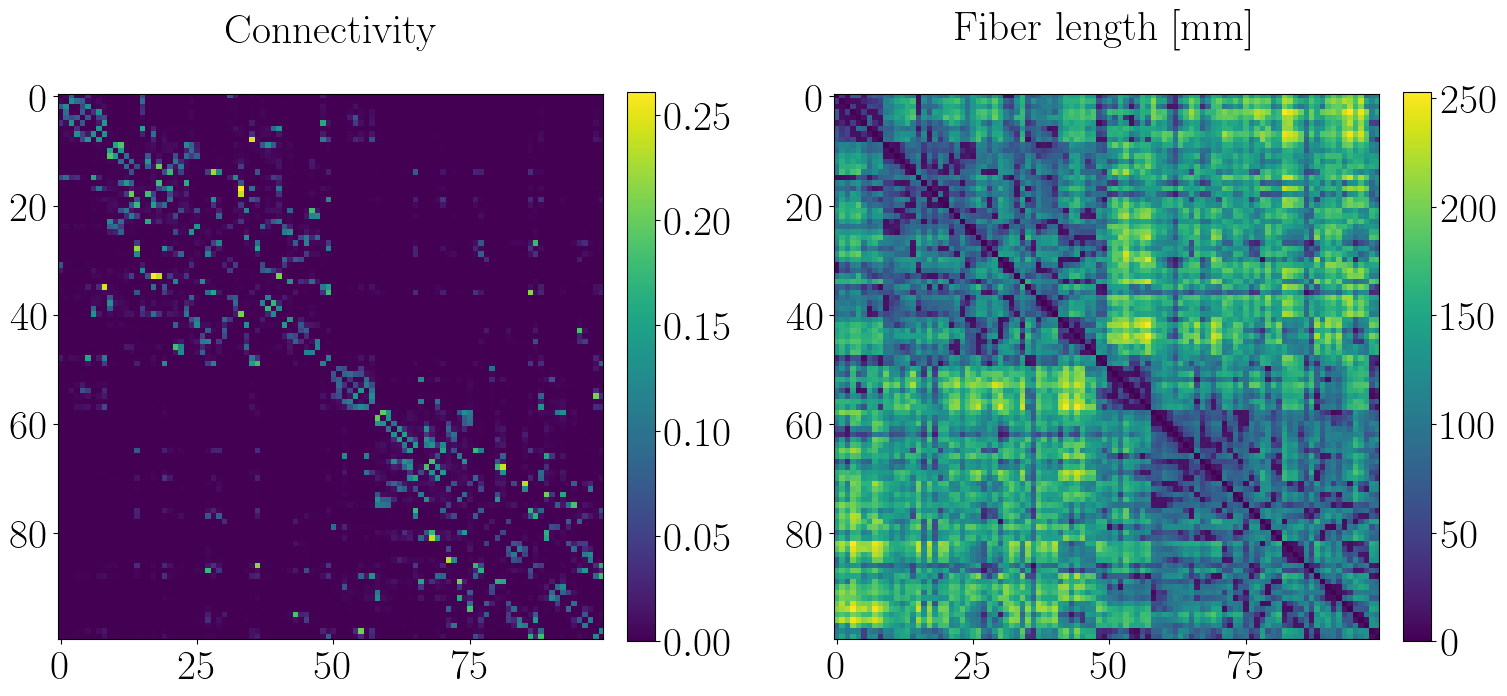

In [4]:
fig, ax = plt.subplots(1,2, figsize=(fig_width, 0.5*fig_width))

ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

heatmap = ax[0].imshow(cmat_av)
ax[0].set_title("Connectivity\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

heatmap = ax[1].imshow(dmat_av)
ax[1].set_title("Fiber length [mm]\n")
bar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.3)

plt.savefig(os.path.join(datadir, "cd_mat.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [6]:
sys = "discrete"

c_norm = nctpy.utils.matrix_normalization((cmat_av), system=sys)
av_c = nctpy.metrics.ave_control(c_norm, sys)
mod_c = nctpy.metrics.modal_control(c_norm)
wnd = np.sum(cmat_av, axis=0)

wnfl = np.zeros((N))
for n in range(N):
    wnfl[n] = sum(cmat_av[n,:]*dmat_av[n,:])

r_coord, theta, phi = get_sphere_coords(coord_data[:,0], coord_data[:,1], coord_data[:,2])

In [41]:
x_array = [av_c, mod_c, wnd]
xlabel = ["Average controllability", "Modal controllability", "Weighted node degree"]

r_mat_cd_cd = np.zeros((len(x_array), len(x_array)))
p_mat_cd_cd = np.zeros((len(x_array), len(x_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(x_array):

        print(xlabel[ix], xlabel[iy])

        if iy == ix: 
            r_mat_cd_cd[ix, iy] = 1.
            p_mat_cd_cd[ix, iy] = 0.

        if iy >= ix: continue

        result = scipy.stats.pearsonr(x, y, method=method)
        r_val = result.statistic
        p_val = result.pvalue
        r_mat_cd_cd[ix, iy] = r_val
        p_mat_cd_cd[ix, iy] = p_val

        if ix < 2:
            r_mat_cd_cd[iy, ix] = r_val
            p_mat_cd_cd[iy, ix] = p_val

Average controllability Average controllability
Average controllability Modal controllability
Average controllability Weighted node degree
Modal controllability Average controllability
Modal controllability Modal controllability
Modal controllability Weighted node degree
Weighted node degree Average controllability
Weighted node degree Modal controllability
Weighted node degree Weighted node degree


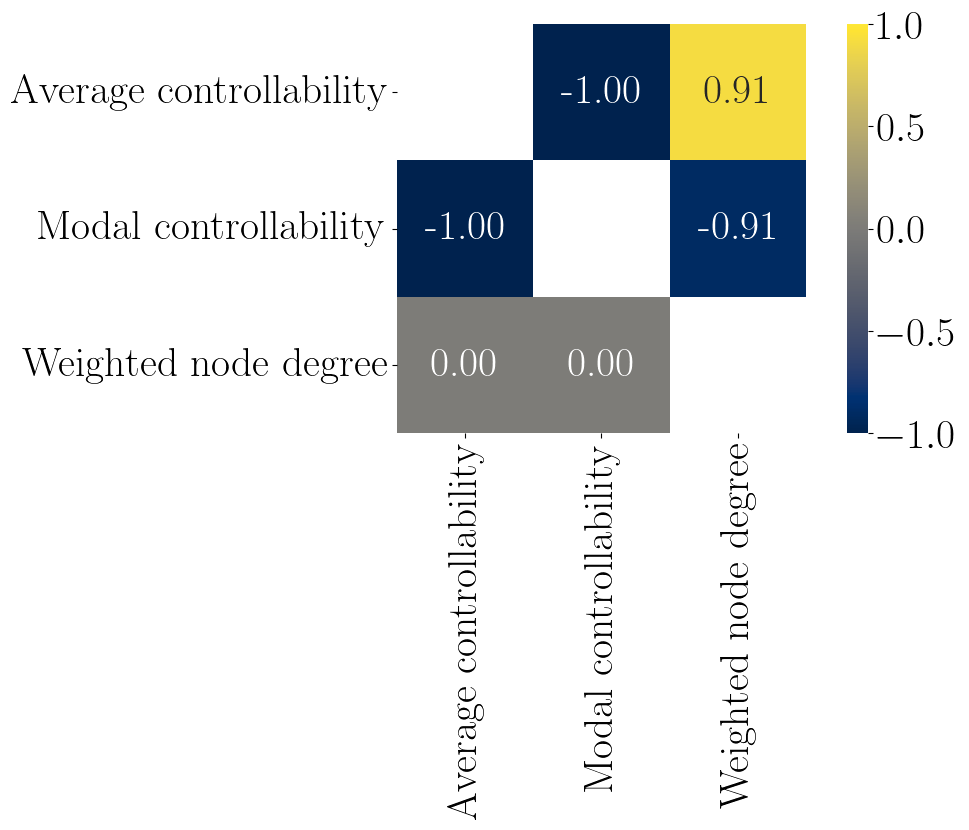

In [51]:
xlabel = ["Average controllability", "Modal controllability", "Weighted node degree"]

annotations = r_mat_cd_cd.copy()

for ix in range(3):
    annotations[ix, ix] = None

for ix in range(len(xlabel)):
    for iy in range(3):
        if p_mat_cd_cd[ix, iy] >= 0.05:
            annotations[ix, iy] = None

for ix in range(len(xlabel)):
    for iy in range(3):
        if np.abs(r_mat_cd_cd[ix, iy]) < 0.0:
            annotations[ix, iy] = None

plt.figure(figsize=(0.6*fig_width,0.3*fig_width))
ax = sns.heatmap(annotations[:3,:].T, annot=True, fmt='.2f', cmap=cmap, yticklabels=xlabel[:3], xticklabels=xlabel, vmin=-1, vmax=1)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90)
plt.yticks(rotation=0) 
plt.savefig(os.path.join(datadir, "corr_mat_cd.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [5]:
dt = 0.1

rng = np.random.default_rng()
method = scipy.stats.PermutationMethod(n_resamples=3. * 1e3, random_state=rng)
cmap = "cividis"

with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_var_L2, d1_var_L2, d2_var_L2] = data_read

with open(os.path.join(datadir, 'wb_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_cc_L2, d1_cc_L2, d2_cc_L2] = data_read

with open(os.path.join(datadir, 'wb_L1.pickle'), 'rb') as f:
    data_read = pickle.load(f)
d0_var_L1, d1_var_L1, d2_var_L1 = data_read

with open(os.path.join(datadir, 'wb_L1_cc.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[d0_cc_L1, d1_cc_L1, d2_cc_L1] = data_read

In [6]:
i0, i1 = 60, 450
i0a, i1a = 2780, 3280
i0a0, i1a0 = 3200, 3650
wi = 0
lim = 1e-8

## cost combo / point task / weight / n

peak_times = np.zeros((4, 3, 3, N))
energy = np.zeros((4, 3, 3, N))
input = np.zeros((4, 3, 3, N))
control_times = np.zeros((4, 3, 3, N))

for wi in range(3):

    for n in range(N):
        energy[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,:]**2 * dt)
        input[0,0,wi,n] = np.sum(d0_var_L2["control"][wi][n,:] * dt)
        energy[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,:]**2 * dt)
        input[0,1,wi,n] = np.sum(d1_var_L2["control"][wi][n,:] * dt)
        energy[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,:]**2 * dt)
        input[0,2,wi,n] = np.sum(d2_var_L2["control"][wi][n,:] * dt)

        energy[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,:]**2 * dt)
        input[2,0,wi,n] = np.sum(d0_cc_L2["control"][wi][n,:] * dt)
        energy[2,1,wi,n] = np.sum(d1_cc_L2["control"][wi][n,:]**2 * dt)
        input[2,1,wi,n] = np.sum(d1_cc_L2["control"][wi][n,:] * dt)
        energy[2,2,wi,n] = np.sum(d2_cc_L2["control"][wi][n,:]**2 * dt)
        input[2,2,wi,n] = np.sum(d2_cc_L2["control"][wi][n,:] * dt)

    for n in range(N):
        peak_times[0,0,wi,n] = scipy.signal.find_peaks(d0_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[0,2,wi,n] = scipy.signal.find_peaks(d2_var_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,0,wi,n] = scipy.signal.find_peaks(d0_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
        peak_times[2,2,wi,n] = scipy.signal.find_peaks(d2_cc_L2["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

    peak_times[0,0,wi,:] -= np.amin(peak_times[0,0,wi,:])
    peak_times[0,2,wi,:] -= np.amin(peak_times[0,2,wi,:])
    peak_times[1,0,wi,:] -= np.amin(peak_times[1,0,wi,:])
    peak_times[1,2,wi,:] -= np.amin(peak_times[1,2,wi,:])
    peak_times[2,0,wi,:] -= np.amin(peak_times[2,0,wi,:])
    peak_times[2,2,wi,:] -= np.amin(peak_times[2,2,wi,:])
    peak_times[3,0,wi,:] -= np.amin(peak_times[3,0,wi,:])
    peak_times[3,2,wi,:] -= np.amin(peak_times[3,2,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L2["control"][wi][n,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_var_L2["control"][wi][n,i0+peaktime_array]))]
        control_times[0,0,wi,n] = peaktime
    control_times[0,0,wi,:] -= np.median(control_times[0,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L2["control"][wi][n,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_var_L2["control"][wi][n,i0+peaktime_array]))]
        control_times[0,2,wi,n] = peaktime
    control_times[0,2,wi,:] -= np.median(control_times[0,2,wi,:])


    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_cc_L2["control"][wi][n,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d0_cc_L2["control"][wi][n,i0+peaktime_array]))]
        control_times[2,0,wi,n] = peaktime
    control_times[2,0,wi,:] -= np.median(control_times[2,0,wi,:])

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_cc_L2["control"][wi][n,i0:i1]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d2_cc_L2["control"][wi][n,i0+peaktime_array]))]
        control_times[2,2,wi,n] = peaktime
    
    control_times[2,2,wi,:] -= np.median(control_times[2,2,wi,:])



    sumact = np.sum(d1_var_L2["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[0,1,wi,n] = scipy.signal.find_peaks(d1_var_L2["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[0,1,wi,:] -= np.amin(peak_times[0,1,wi,:])

    enmax_ind = np.argmax(energy[0,1,wi,:])
    ia0_= scipy.signal.find_peaks(d1_var_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_var_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L2["control"][wi][n,ia0_:ia1_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_var_L2["control"][wi][n,ia0_+peaktime_array]))]
        control_times[0,1,wi,n] = peaktime
    control_times[0,1,wi,enmax_ind] = 0.

    
    sumact = np.sum(d1_cc_L2["state"][wi][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)
    

    for n in range(N):
        peak_times[2,1,wi,n] = scipy.signal.find_peaks(d1_cc_L2["state"][wi][n,0,:minact], height=0.7)[0][-1]
    peak_times[2,1,wi,:] -= np.amin(peak_times[2,1,wi,:])

    enmax_ind = np.argmax(energy[2,1,wi,:])
    ia0_ = scipy.signal.find_peaks(d1_cc_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_cc_L2["state"][wi][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_cc_L2["control"][wi][n,ia0_:ia1_]))[0]
        peaktime = peaktime_array[np.argmax(np.abs(d1_cc_L2["control"][wi][n,ia0_+peaktime_array]))]
        control_times[2,1,wi,n] = peaktime
    control_times[2,1,wi,enmax_ind] = 0.

In [7]:
v00, v01 = 0, 1
v10, v11 = 3,5
v20, v21 = 8, 10

c00, c01 = 3, 10
c10, c11 = 7, 10
c20, c21 = 3, 7

for n in range(N):

    energy[1,0,0,n] = np.sum(d0_var_L1["control"][v00][n,:]**2 * dt)
    input[1,0,0,n] = np.sum(d0_var_L1["control"][v00][n,:]) * dt
    energy[1,1,0,n] = np.sum(d1_var_L1["control"][v10][n,:]**2 * dt)
    input[1,1,0,n] = np.sum(d1_var_L1["control"][v10][n,:]) * dt
    energy[1,2,0,n] = np.sum(d2_var_L1["control"][v20][n,:]**2 * dt)
    input[1,2,0,n] = np.sum(d2_var_L1["control"][v20][n,:]) * dt

    energy[1,0,1,n] = np.sum(d0_var_L1["control"][v01][n,:]**2 * dt)
    input[1,0,1,n] = np.sum(d0_var_L1["control"][v10][n,:]) * dt
    energy[1,1,1,n] = np.sum(d1_var_L1["control"][v11][n,:]**2 * dt)
    input[1,1,1,n] = np.sum(d1_var_L1["control"][v11][n,:]) * dt
    energy[1,2,1,n] = np.sum(d2_var_L1["control"][v21][n,:]**2 * dt)
    input[1,2,1,n] = np.sum(d2_var_L1["control"][v21][n,:]) * dt

    energy[3,0,0,n] = np.sum(d0_cc_L1["control"][c00][n,:]**2 * dt)
    input[3,0,0,n] = np.sum(d0_cc_L1["control"][c00][n,:]) * dt
    energy[3,1,0,n] = np.sum(d1_cc_L1["control"][c10][n,:]**2 * dt)
    input[3,1,0,n] = np.sum(d1_cc_L1["control"][c10][n,:]) * dt
    energy[3,2,0,n] = np.sum(d2_cc_L1["control"][c20][n,:]**2 * dt)
    input[3,2,0,n] = np.sum(d2_cc_L1["control"][c20][n,:]) * dt

    energy[3,0,1,n] = np.sum(d0_cc_L1["control"][c01][n,:]**2 * dt)
    input[3,0,1,n] = np.sum(d0_cc_L1["control"][c01][n,:]) * dt
    energy[3,1,1,n] = np.sum(d1_cc_L1["control"][c11][n,:]**2 * dt)
    input[3,1,1,n] = np.sum(d1_cc_L1["control"][c11][n,:]) * dt
    energy[3,2,1,n] = np.sum(d2_cc_L1["control"][c21][n,:]**2 * dt)
    input[3,2,1,n] = np.sum(d2_cc_L1["control"][c21][n,:]) * dt

for n in range(N):
    peak_times[1,0,:,n] = scipy.signal.find_peaks(d0_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
    peak_times[1,2,:,n] = scipy.signal.find_peaks(d2_var_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
    peak_times[3,0,:,n] = scipy.signal.find_peaks(d0_cc_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]
    peak_times[3,2,:,n] = scipy.signal.find_peaks(d2_cc_L1["state_uncontrolled"][n,0,:], height=0.7)[0][-1]

for wi in [0,1]:
    peak_times[1,0,wi,:] -= np.amin(peak_times[1,0,wi,:])
    peak_times[1,2,wi,:] -= np.amin(peak_times[1,2,wi,:])
    peak_times[3,0,wi,:] -= np.amin(peak_times[3,0,wi,:])
    peak_times[3,2,wi,:] -= np.amin(peak_times[3,2,wi,:])

for [wi, ind_l1] in [[0, v00], [1, v01]]:
    print(wi, ind_l1)

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_var_L1["control"][ind_l1][n,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d0_var_L1["control"][ind_l1][n,i0+peaktime_array]))]
            control_times[1,0,wi,n] = peaktime

    valvec = []
    for n in range(N):
        if control_times[1,0,wi,n] != 0:    
            valvec.append(control_times[1,0,wi,n])
    for n in range(N):
        if control_times[1,0,wi,n] != 0:
            control_times[1,0,wi,n] -= np.median(valvec)

for [wi, ind_l1] in [[0, v20], [1, v21]]:

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_var_L1["control"][ind_l1][n,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d2_var_L1["control"][ind_l1][n,i0+peaktime_array]))]
            if np.abs(d2_var_L1["control"][ind_l1][n,peaktime]) > lim:
                control_times[1,2,wi,n] = peaktime

    valvec = []
    for n in range(N):
        if control_times[1,2,wi,n] != 0:
            valvec.append(control_times[1,0,wi,n])
    for n in range(N):
        if control_times[1,2,wi,n] != 0:
            control_times[1,2,wi,n] -= np.median(valvec)


for [wi, ind_l1] in [[0, c00], [1, c01]]:
    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d0_cc_L1["control"][ind_l1][n,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d0_cc_L1["control"][ind_l1][n,i0+peaktime_array]))]
            control_times[3,0,wi,n] = peaktime

    minct = np.amin(control_times[3,0,wi,:])
    for n in range(N):
        if control_times[3,0,wi,n] != 0:    
            control_times[3,0,wi,n] -= minct

for [wi, ind_l1] in [[0, c20], [1, c21]]:
    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d2_cc_L1["control"][ind_l1][n,i0:i1]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d2_cc_L1["control"][ind_l1][n,i0+peaktime_array]))]
            control_times[3,2,wi,n] = peaktime

    minct = np.amin(control_times[3,2,wi,:])
    for n in range(N):
        if control_times[3,2,wi,n] != 0:    
            control_times[3,2,wi,n] -= minct

for [wi, ind_l1] in [[0, v10], [1, v11]]:

    sumact = np.sum(d1_var_L1["state"][ind_l1][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[1,1,wi,n] = scipy.signal.find_peaks(d1_var_L1["state"][ind_l1][n,0,:minact], height=0.7)[0][-1]
    peak_times[1,1,wi,:] -= np.amin(peak_times[1,1,wi,:])

    enmax_ind = 71
    ia0_ = scipy.signal.find_peaks(d1_var_L1["state"][ind_l1][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_var_L1["state"][ind_l1][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_var_L1["control"][ind_l1][n,ia0_:ia1_]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d1_var_L1["control"][ind_l1][n,ia0_+peaktime_array]))]
            control_times[1,1,wi,n] = peaktime
    control_times[1,1,wi,enmax_ind] = 0.

for [wi, ind_l1] in [[0, c10], [1, c11]]:

    sumact = np.sum(d1_cc_L1["state"][ind_l1][:,0,2000:], axis=0)
    minact = 2000+np.argmin(sumact)

    for n in range(N):
        peak_times[3,1,wi,n] = scipy.signal.find_peaks(d1_cc_L1["state"][ind_l1][n,0,:minact], height=0.7)[0][-1]
    peak_times[3,1,wi,:] -= np.amin(peak_times[3,1,wi,:])

    enmax_ind = 9
    ia0_ = scipy.signal.find_peaks(d1_cc_L1["state"][ind_l1][enmax_ind,0,:], height=0.7)[0][-3]
    ia1_ = scipy.signal.find_peaks(d1_cc_L1["state"][ind_l1][enmax_ind,0,:], height=0.7)[0][-1]

    for n in range(N):
        peaktime_array = scipy.signal.find_peaks(np.abs(d1_cc_L1["control"][ind_l1][n,ia0_:ia1_]))[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(np.abs(d1_cc_L1["control"][ind_l1][n,ia0_+peaktime_array]))]
            control_times[3,1,wi,n] = peaktime
    control_times[3,1,wi,enmax_ind] = 0.

0 0
1 1


In [8]:
peak_times *= dt
control_times *= dt

(100, 2, 4000)
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
e

NameError: name 'argmin_A' is not defined

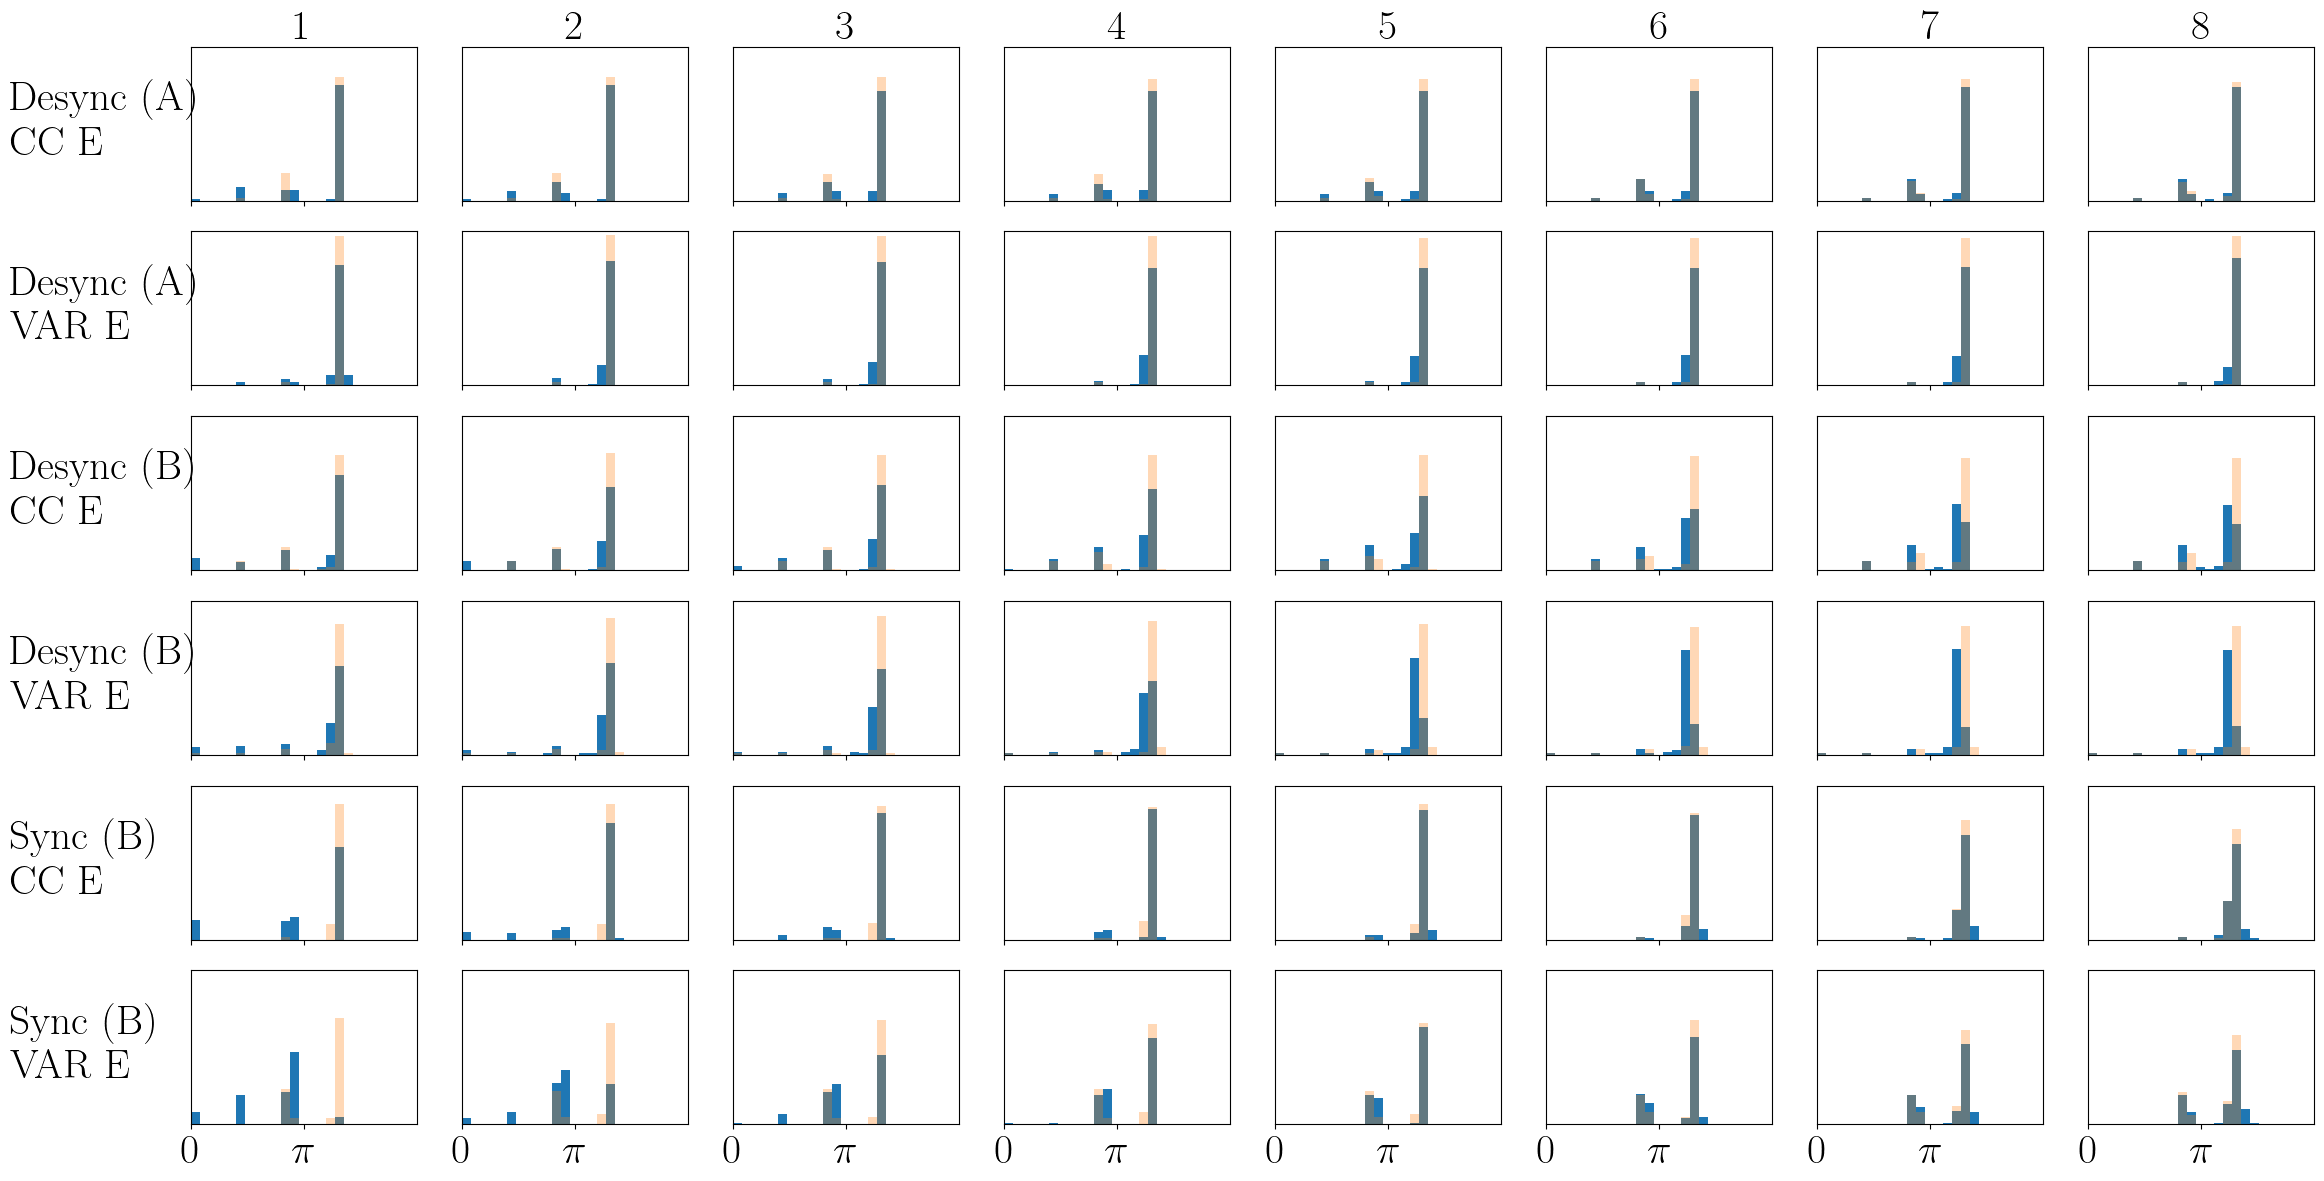

In [9]:
def get_period(x):
    peaks = scipy.signal.find_peaks(x, height=0.7)[0]
    pe_list = []

    for pi in range(len(peaks)-1):
        pe_list.append(peaks[pi+1] - peaks[pi])

    return np.mean(pe_list)

phases = np.zeros((4, 3, 3, N, 2))

period_b = []
period_a = []
period_c = []

period_uncontrolled = np.zeros((3, N))

print(d0_var_L2["state_uncontrolled"].shape)
for n in range(N):
    period_uncontrolled[0,n] = get_period(d0_var_L2["state_uncontrolled"][n,0,:])
    period_uncontrolled[1,n] = get_period(d1_var_L2["state_uncontrolled"][n,0,:])
    period_uncontrolled[2,n] = get_period(d2_var_L2["state_uncontrolled"][n,0,:])
    
    period_b.append(get_period(d0_var_L2["state_uncontrolled"][n,0,:]))
    period_a.append(get_period(d2_var_L2["state_uncontrolled"][n,0,:]))
    period_c.append(get_period(d1_var_L2["state_uncontrolled"][n,0,:]))

period_b = np.mean(period_b)
period_a = np.mean(period_a)
period_c = np.mean(period_c)


fig, ax = plt.subplots(6, 8, figsize = (fig_width_landscape,0.79*(15/23.2)*fig_width_landscape), sharex=True, sharey=True)

for k in range(8):

    for task, d in zip([0,2], [d0_var_L2, d0_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 0")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period_b)

                if len(phs) > 0:
                    phases[task,0,wi, n, 0] = np.mean(phs)
                    phases[task,0,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d2_var_L2, d2_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 2")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period_a)

                if len(phs) > 0:
                    phases[task,2,wi, n, 0] = np.mean(phs)
                    phases[task,2,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d1_var_L2, d1_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(7-k, 7-k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 1")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period_c)

                if len(phs) > 0:
                    phases[task,1,wi, n, 0] = np.mean(phs)
                    phases[task,1,wi, n, 1] = np.std(phs)

    ax[0,0].set_xlim(0, 2*np.pi)

    kwargs = dict(histtype='stepfilled', alpha=1, density=True, bins=np.arange(0, 6.1, 0.25), ec="k")
    ax[0,k].hist(np.mean(phases[0,2,:,:,0], axis=0), **kwargs)
    ax[1,k].hist(np.mean(phases[2,2,:,:,0], axis=0), **kwargs)
    ax[2,k].hist(np.mean(phases[0,0,:,:,0], axis=0), **kwargs)
    ax[3,k].hist(np.mean(phases[2,0,:,:,0], axis=0), **kwargs)
    ax[4,k].hist(np.mean(phases[0,1,:,:,0], axis=0), **kwargs)
    ax[5,k].hist(np.mean(phases[2,1,:,:,0], axis=0), **kwargs)

    ax[0,k].set_title(str(k+1))

#########################################################
for k in range(8):

    for task, d in zip([0,2], [d0_var_L2, d0_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 0")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)

                if len(phs) > 0:
                    phases[task,0,wi, n, 0] = np.mean(phs)
                    phases[task,0,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d2_var_L2, d2_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 2")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)

                if len(phs) > 0:
                    phases[task,2,wi, n, 0] = np.mean(phs)
                    phases[task,2,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d1_var_L2, d1_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(7-k, 7-k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0

                    if period == 0: continue

                    inittime = tps0
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 1")
                        continue

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)

                if len(phs) > 0:
                    phases[task,1,wi, n, 0] = np.mean(phs)
                    phases[task,1,wi, n, 1] = np.std(phs)

    kwargs = dict(histtype='stepfilled', alpha=0.3, color=colmap(0.1), density=True, bins=np.arange(0, 6.1, 0.25), ec="k")

    ax[0,k].hist(np.mean(phases[0,2,:,:,0], axis=0), **kwargs)
    ax[1,k].hist(np.mean(phases[2,2,:,:,0], axis=0), **kwargs)
    ax[2,k].hist(np.mean(phases[0,0,:,:,0], axis=0), **kwargs)
    ax[3,k].hist(np.mean(phases[2,0,:,:,0], axis=0), **kwargs)
    ax[4,k].hist(np.mean(phases[0,1,:,:,0], axis=0), **kwargs)
    ax[5,k].hist(np.mean(phases[2,1,:,:,0], axis=0), **kwargs)
#####################################################

ax[0,0].set_ylim(0,4.0)
ax[-1,0].set_xticks([0, np.pi])
ax[-1,0].set_xticklabels(["0", r"$\pi$"])
ax[0,0].set_yticks([])
ax[0,0].set_ylabel("Desync (A)\n CC E", rotation=0, horizontalalignment="left")
ax[1,0].set_ylabel("Desync (A)\n VAR E", rotation=0, horizontalalignment="left")
ax[2,0].set_ylabel("Desync (B)\n CC E", rotation=0, horizontalalignment="left")
ax[3,0].set_ylabel("Desync (B)\n VAR E", rotation=0, horizontalalignment="left")
ax[4,0].set_ylabel("Sync (B)\n CC E", rotation=0, horizontalalignment="left")
ax[5,0].set_ylabel("Sync (B)\n VAR E", rotation=0, horizontalalignment="left")

for k in range(6):
    ax[k,0].yaxis.set_label_coords(-0.8,0.25)

for k in range(8):
    ax[0,k].vlines(argmin_A, 0, 6, linestyle="--", color="gray")
    ax[1,k].vlines(argmin_A, 0, 6, linestyle="--", color="gray")
    ax[2,k].vlines(argmin_B, 0, 6, linestyle="--", color="gray")
    ax[3,k].vlines(argmin_B, 0, 6, linestyle="--", color="gray")
    ax[4,k].vlines(argmin_B, 0, 6, linestyle="--", color="gray")
    ax[5,k].vlines(argmin_B, 0, 6, linestyle="--", color="gray")
#
plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.0, hspace=0.0)
plt.savefig(os.path.join(datadir, "hist_phases.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [10]:
period_all = np.zeros((4, 3, 3, N))
amplitude = np.zeros((4, 3, 3, N))

for k in range(1):

    for task, d in zip([0,2], [d0_var_L2, d0_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0
                    period_all[task, 0, wi, n] = period

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 0")
                        continue

                    cpeaktime_ = np.argmax(np.abs(d["control"][wi][n,inittime:tps1+1]))
                    amplitude[task,0,wi, n] = d["control"][wi][n,inittime+cpeaktime_]

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)#period_b)

                if len(phs) > 0:
                    phases[task,0,wi, n, 0] = np.mean(phs)
                    phases[task,0,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d2_var_L2, d2_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(k, k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0
                    period_all[task, 2, wi, n] = period

                    if period == 0: continue

                    inittime = tps0+50
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 2")
                        continue

                    cpeaktime_ = np.argmax(np.abs(d["control"][wi][n,inittime:tps1+1]))
                    amplitude[task,2,wi, n] = d["control"][wi][n,inittime+cpeaktime_]

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)#period_a)

                if len(phs) > 0:
                    phases[task,2,wi, n, 0] = np.mean(phs)
                    phases[task,2,wi, n, 1] = np.std(phs)


    for task, d in zip([0,2], [d1_var_L2, d1_cc_L2]):
        for wi in range(3):

            for n in range(N):
                phs = []
                for tpind in range(1-k, 1-k+1):
                
                    tps0, tps1 = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]
                    period = tps1 - tps0
                    period_all[task, 1, wi, n] = period

                    if period == 0: continue

                    inittime = tps0
                    cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps1+1]), height=0.0001)[0]

                    if len(cpeaktime) == 0:
                        print("empty 1")
                        continue

                    cpeaktime_ = np.argmax(np.abs(d["control"][wi][n,inittime:tps1+1]))
                    amplitude[task,1,wi, n] = d["control"][wi][n,inittime+cpeaktime_]

                    peaktime = (inittime - tps0) + cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]
                    phs.append(2. * np.pi * peaktime/period)#period_c)

                if len(phs) > 0:
                    phases[task,1,wi, n, 0] = np.mean(phs)
                    phases[task,1,wi, n, 1] = np.std(phs)


empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 0
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2
empty 2


/tmp/ipykernel_557033/654140392.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
/tmp/ipykernel_557033/654140392.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.


findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not

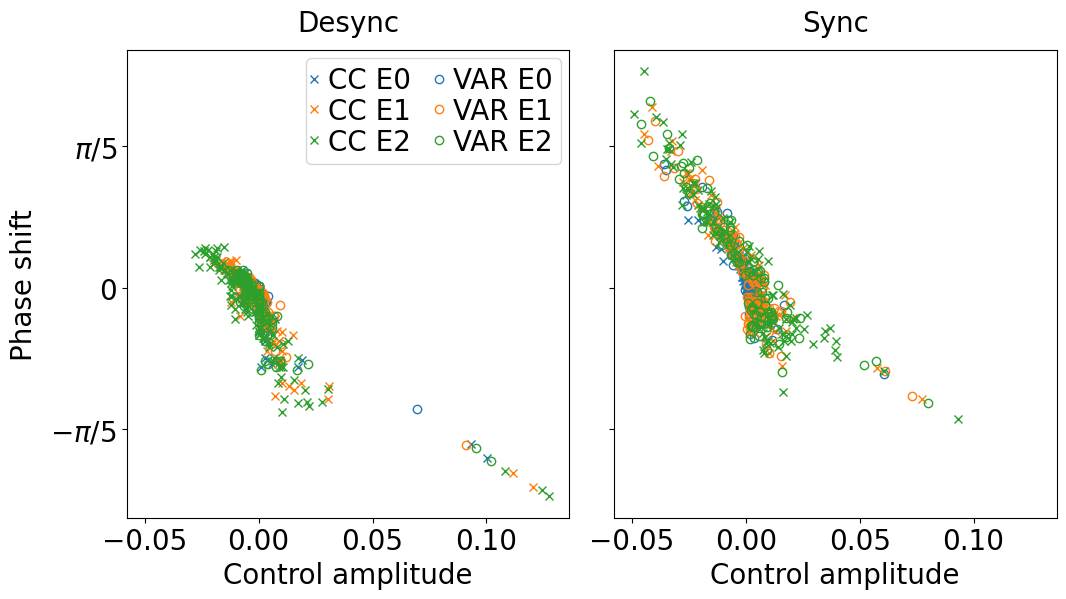

In [27]:
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 3
plt.rcParams['text.usetex'] = False

colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)

xlabel = r"Control amplitude"
ylabel = [r"Phase shift"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('tab10')
marker= ["o", "x"]
mew = 1

for wi in range(3):
    ax[0].plot(amplitude[0, 0, wi, :], 2. * np.pi * (period_all[0, 0, wi, :]/period_uncontrolled[0,:] - 1.), marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[0].plot(amplitude[2, 0, wi, :], 2. * np.pi * (period_all[2, 0, wi, :]/period_uncontrolled[0,:] - 1), marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")

    ax[1].plot(amplitude[0, 1, wi, :], 2. * np.pi * (period_all[0, 1, wi, :]/period_uncontrolled[1,:] - 1), marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    ax[1].plot(amplitude[2, 1, wi, :], 2. * np.pi * (period_all[2, 1, wi, :]/period_uncontrolled[1,:] - 1), marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")

ax[0].set_ylabel(ylabel[0])
ax[0].set_yticks([-0.2*np.pi, 0, 0.2*np.pi])
ax[0].set_yticklabels([r"$-\pi/5$", r"$0$", r"$\pi/5$"])
ax[0].yaxis.set_label_coords(-0.2,.5)

ax[0].text(0.5, 1.04, r"Desync", transform=ax[0].transAxes, horizontalalignment="center")
ax[1].text(0.5, 1.04, r"Sync", transform=ax[1].transAxes, horizontalalignment="center")

for ix in range(2):
    ax[ix].set_xlabel(xlabel)

legend_elements = [
                   Line2D([0], [0], linestyle="none", color=colmap(0), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E2'),
                   Line2D([0], [0], linestyle="none", color=colmap(0), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E2'),
                   ]

ax[0].legend(handles=legend_elements, loc="upper right", labelspacing=0.1, handlelength=0., handletextpad=0.5, frameon=True, ncol=2, columnspacing=1, borderpad=0.3, borderaxespad=0.3)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.1, hspace=0.2)
plt.savefig("period_amp_B.pdf", bbox_inches='tight')

plt.show()

-14.0
240 662


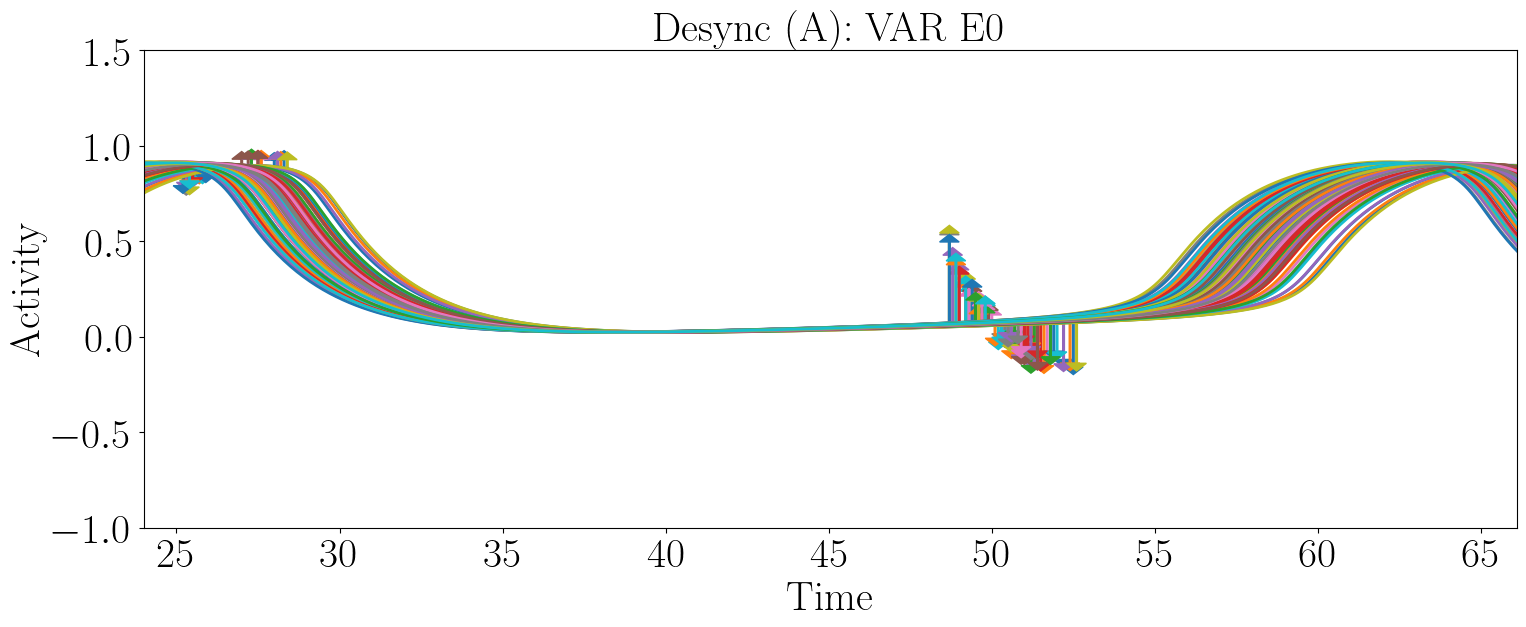

-14.0
191 671


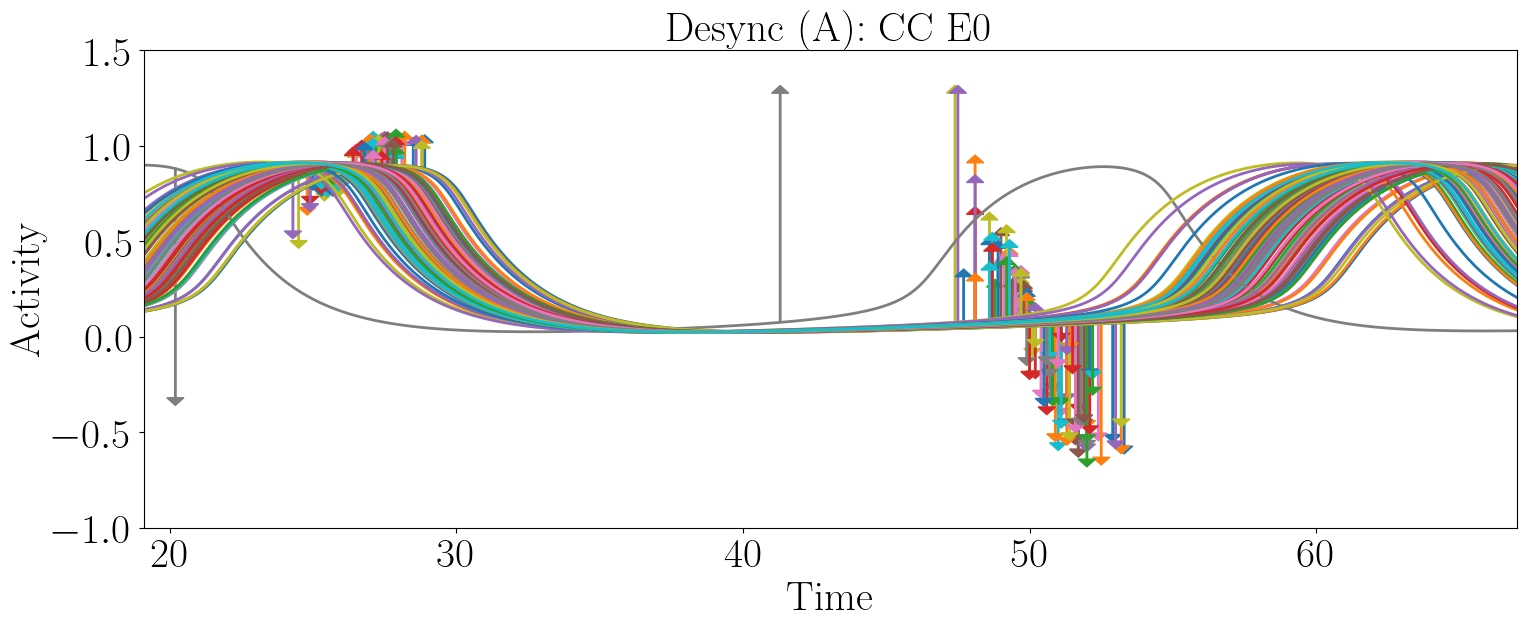

-36.0
178 791


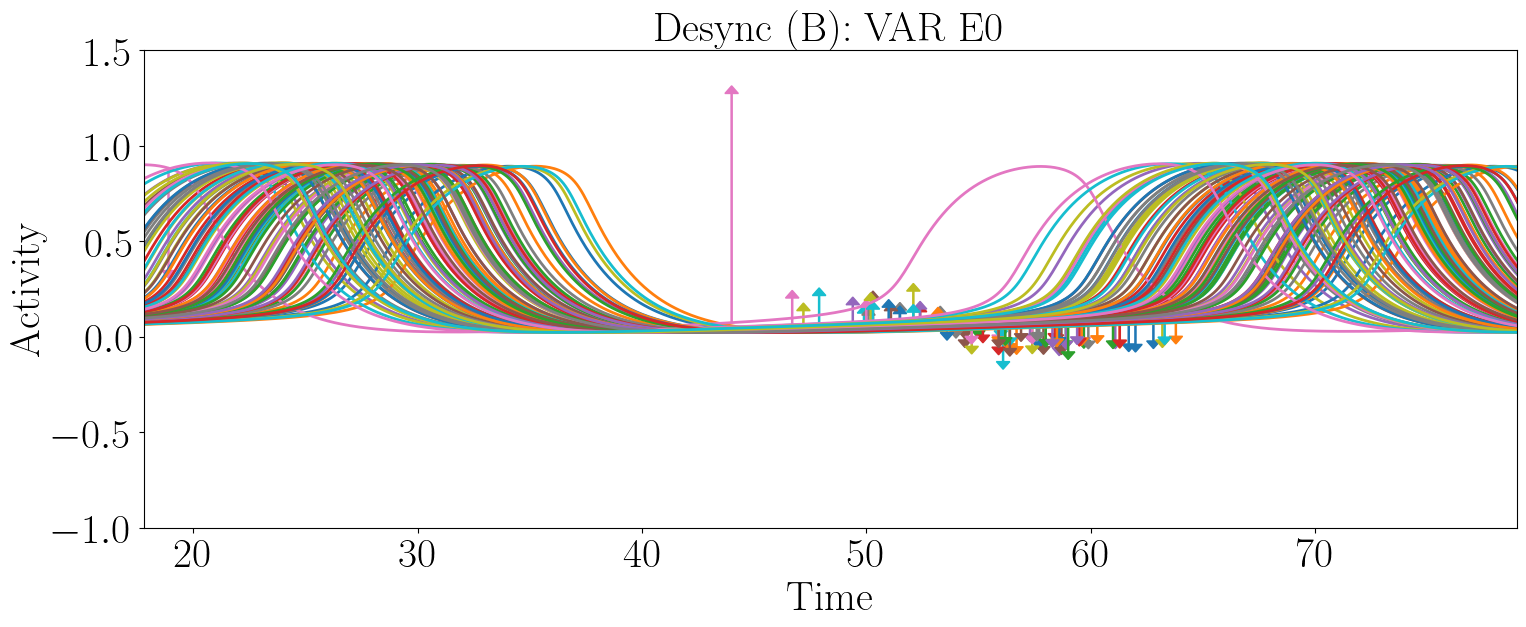

-42.0
162 799


KeyboardInterrupt: 

In [18]:
def plot_snippet(wi, d, lim, title, filename, maxarrowlength, factor, last = False):
    fig = plt.figure(figsize=(fig_width, 0.35*fig_width))
    ax = fig.add_subplot(111)

    time = np.arange(0., 400.+dt, dt)

    p0min = 10000
    p1max = 0

    amplitude = np.zeros((N))
    
    for n in range(N):

        line = ax.plot(time, d["state"][wi][n,0,:])
        col = line[0].get_color()        
        
        if last:
            [i0, i1] = scipy.signal.find_peaks(d["state"][wi][n,0,:])[0][-2:]
        else:
            [i0, i1] = scipy.signal.find_peaks(d["state"][wi][n,0,:])[0][:2]

        if i0 < p0min:
            p0min = i0

        if i1 > p1max:
            p1max = i1

        peaktime_array = scipy.signal.find_peaks(d["control"][wi][n,i0:i1+1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(d["control"][wi][n,i0+peaktime_array])]
            amp = d["control"][wi][n,i0+peaktime]
            amplitude[n] = amp
            if np.abs(amp) > lim:
                arrowlength = min(maxarrowlength, factor*amp)
                plt.arrow((i0+peaktime)*dt, d["state"][wi][n,0,i0+peaktime], 0, arrowlength, width=0.05, head_width=0.6, head_length=0.04, length_includes_head=False, color=col)
        peaktime_array = scipy.signal.find_peaks(-d["control"][wi][n,i0:i1])[0]
        if len(peaktime_array) > 0:
            peaktime = peaktime_array[np.argmax(-d["control"][wi][n,i0+peaktime_array])]
            amp = d["control"][wi][n,i0+peaktime]
            if np.abs(amp) > np.abs(amplitude[n]):
                amplitude[n] = amp
            if np.abs(amp) > lim:
                arrowlength = max(-maxarrowlength, factor*amp)
                plt.arrow((i0+peaktime)*dt, d["state"][wi][n,0,i0+peaktime], 0, arrowlength, width=0.05, head_width=0.6, head_length=0.04, length_includes_head=False, color=col)

    print(np.sum(np.sign(amplitude)))


    print(p0min, p1max)
    if last:
        p0min = max(p0min, 3300)
    ax.set_xlim(p0min*dt, (p1max-1)*dt)

    ax.set_title(title+str(wi))
    ax.set_ylabel("Activity")
    ax.set_xlabel("Time")
    ax.set_ylim(-1., 1.5)
    plt.savefig(os.path.join(datadir, filename), bbox_inches='tight', dpi=300)
    plt.show()

    return amplitude

lim = 1. * 1e-3

amplitude = np.zeros((4, 3, 3, N))

scale = 4./0.1  # cap at 0.1
cap = 1.2#1.2

for wi in range(3):

    d = d2_var_L2.copy()
    amplitude[0, 2, wi, :] = plot_snippet(wi, d, lim, "Desync (A): VAR E", "phases_A_VAR_E"+str(wi)+".jpg", cap, scale)

    d = d2_cc_L2.copy()
    amplitude[2, 2, wi, :] = plot_snippet(wi, d, lim, "Desync (A): CC E", "phases_A_CC_E"+str(wi)+".jpg", cap, scale)

    d = d0_var_L2.copy()
    amplitude[0, 0, wi, :] = plot_snippet(wi, d, lim, "Desync (B): VAR E", "phases_B_VAR_E"+str(wi)+".jpg", cap, scale)

    d = d0_cc_L2.copy()
    amplitude[2, 0, wi, :] = plot_snippet(wi, d, lim, "Desync (B): CC E", "phases_B_CC_E"+str(wi)+".jpg", cap, scale)

    d = d1_var_L2.copy()
    amplitude[0, 1, wi, :] = plot_snippet(wi, d, lim, "Sync (B): VAR E", "phases_syncB_VAR_E"+str(wi)+".jpg", cap, scale, last=True)

    d = d1_cc_L2.copy()
    amplitude[2, 1, wi, :] = plot_snippet(wi, d, lim, "Sync (B): CC E", "phases_syncB_CC_E"+str(wi)+".jpg", cap, scale, last=True)

/tmp/ipykernel_1702821/3751676093.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern'

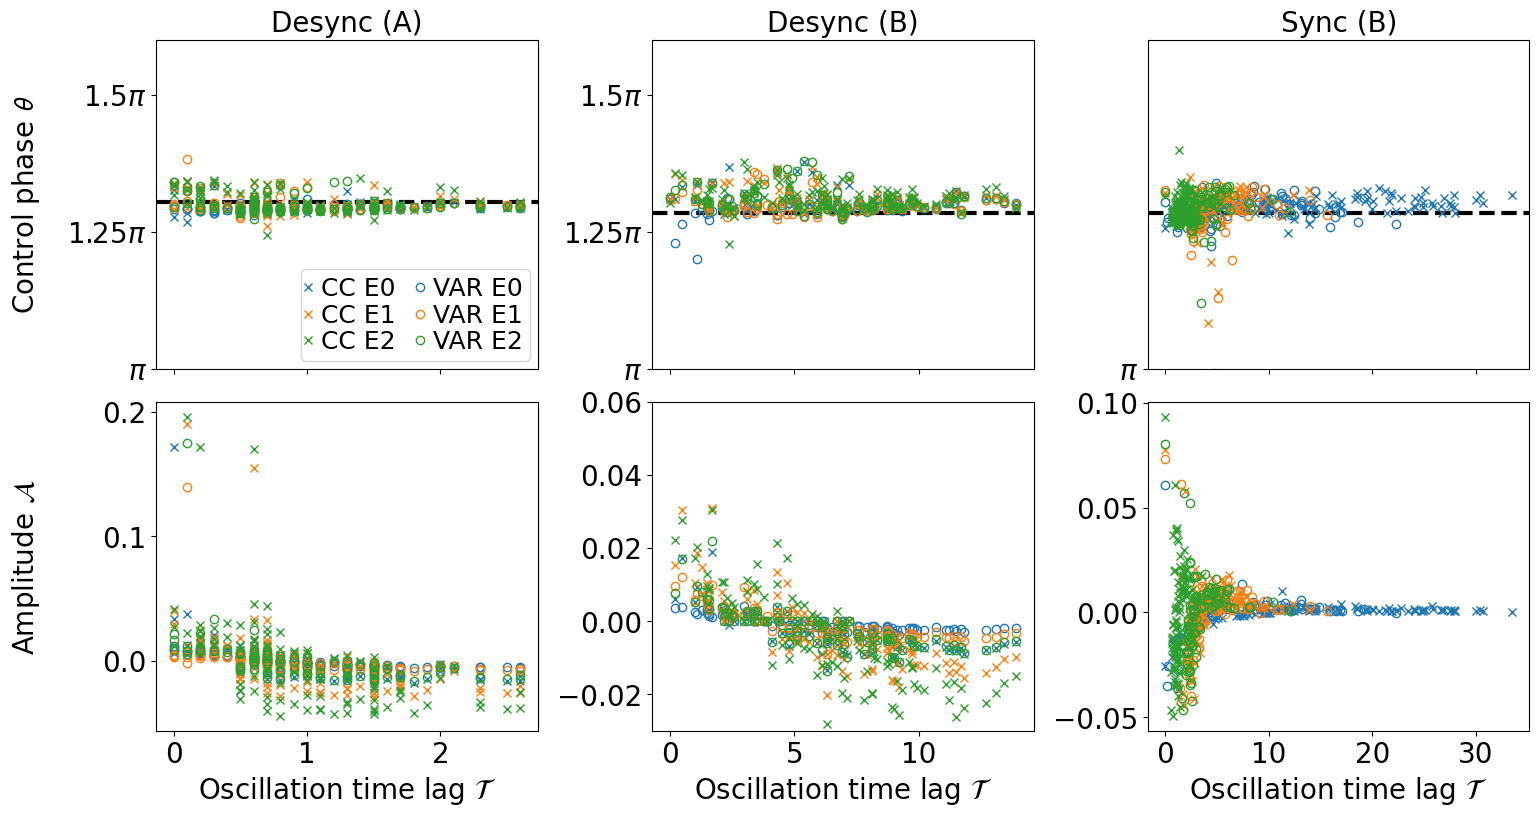

In [21]:
xlabel = r"Oscillation time lag $\mathcal{T}$"
ylabel = [r"Control phase $\mathcal{\theta}$", r"Amplitude $\mathcal{A}$", r"Period $\mathcal{P}$"]
titles = ["Desync (A)", "Desync (B)", "Sync (B)"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('tab10')
marker= ["o", "x"]
mew = 1

x_array = peak_times[0,:]

fig, ax = plt.subplots(2, 3, figsize=(fig_width,0.5*fig_width), sharex="col")

for wi in range(3):
    
    ax[0,0].errorbar(peak_times[0, 2, wi, :], phases[0, 2, wi, :, 0], yerr=phases[0, 2, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 2, ", wi, scipy.stats.pearsonr(peak_times[0, 2, wi, :], phases[0, 2, wi, :, 0], method=method).pvalue)
    ax[1,0].plot(peak_times[0, 2, wi, :], amplitude[0, 2, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 2, ", wi, scipy.stats.pearsonr(peak_times[0, 2, wi, :], amplitude[0, 2, wi, :], method=method).pvalue)

    ax[0,0].errorbar(peak_times[2, 2, wi, :], phases[2, 2, wi, :, 0], yerr=phases[2, 2, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 2, ", wi, scipy.stats.pearsonr(peak_times[2, 2, wi, :], phases[2, 2, wi, :, 0], method=method).pvalue)
    ax[1,0].plot(peak_times[2, 2, wi, :], amplitude[2, 2, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 2, ", wi, scipy.stats.pearsonr(peak_times[2, 2, wi, :], amplitude[2, 2, wi, :], method=method).pvalue)
    
    ax[0,1].errorbar(peak_times[0, 0, wi, :], phases[0, 0, wi, :, 0], yerr=phases[0, 0, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 0, ", wi, scipy.stats.pearsonr(peak_times[0, 0, wi, :], phases[0, 0, wi, :, 0], method=method).pvalue)
    ax[1,1].plot(peak_times[0, 0, wi, :], amplitude[0, 0, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 0, ", wi, scipy.stats.pearsonr(peak_times[0, 0, wi, :], amplitude[0, 0, wi, :], method=method).pvalue)
    
    ax[0,1].errorbar(peak_times[2, 0, wi, :], phases[2, 0, wi, :, 0], yerr=phases[2, 0, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 0, ", wi, scipy.stats.pearsonr(peak_times[2, 0, wi, :], phases[2, 0, wi, :, 0], method=method).pvalue)
    ax[1,1].plot(peak_times[2, 0, wi, :], amplitude[2, 0, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 0, ", wi, scipy.stats.pearsonr(peak_times[2, 0, wi, :], amplitude[2, 0, wi, :], method=method).pvalue)

    ax[0,2].errorbar(peak_times[0, 1, wi, :], phases[0, 1, wi, :, 0], yerr=phases[0, 1, wi, :, 1], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 1, ", wi, scipy.stats.pearsonr(peak_times[0, 1, wi, :], phases[0, 1, wi, :, 0], method=method).pvalue)
    ax[1,2].plot(peak_times[0, 1, wi, :], amplitude[0, 1, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 1, ", wi, scipy.stats.pearsonr(peak_times[0, 1, wi, :], amplitude[0, 1, wi, :], method=method).pvalue)
    
    ax[0,2].errorbar(peak_times[2, 1, wi, :], phases[2, 1, wi, :, 0], yerr=phases[2, 1, wi, :, 1], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 1, ", wi, scipy.stats.pearsonr(peak_times[2, 1, wi, :], phases[2, 1, wi, :, 0], method=method).pvalue)
    ax[1,2].plot(peak_times[2, 1, wi, :], amplitude[2, 1, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 1, ", wi, scipy.stats.pearsonr(peak_times[2, 1, wi, :], amplitude[2, 1, wi, :], method=method).pvalue)

ax[0,0].set_ylabel(ylabel[0])
ax[1,0].set_ylabel(ylabel[1])
ax[1,1].set_ylim(-0.03, 0.06)

for ix in [0]:
    ax[ix,0].set_yticks([np.pi, 1.25*np.pi, 1.5*np.pi, 1.75*np.pi])
    ax[ix,0].set_yticklabels([r"$\pi$", r"$1.25\pi$", r"$1.5 \pi$", r"$1.75 \pi$"])
    ax[ix,0].set_ylim([np.pi, 1.6*np.pi])

    ax[ix,1].set_yticks([np.pi, 1.25*np.pi, 1.5*np.pi, 1.75*np.pi])
    ax[ix,1].set_yticklabels([r"$\pi$", r"$1.25\pi$", r"$1.5 \pi$", r"$1.75 \pi$"])
    ax[ix,1].set_ylim([np.pi, 1.6*np.pi])

    ax[ix,2].set_yticks([0., np.pi, 2.*np.pi])
    ax[ix,2].set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax[ix,2].set_ylim([np.pi, 1.6*np.pi])

    ax[ix,0].axhline(y=argmin_A, color='k', linestyle="--")
    ax[ix,1].axhline(y=argmin_B, color='k', linestyle="--")
    ax[ix,2].axhline(y=argmin_B, color='k', linestyle="--")

for ix in range(3):
    ax[0,ix].set_title(titles[ix])
    ax[1,ix].set_xlabel(xlabel)

ax[0,0].yaxis.set_label_coords(-0.3,0.5)
ax[1,0].yaxis.set_label_coords(-0.3,0.5)

legend_elements = [
                   Line2D([0], [0], linestyle="none", color=colmap(0), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="x", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='CC E2'),
                   Line2D([0], [0], linestyle="none", color=colmap(0), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E0'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.1), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E1'),
                   Line2D([0], [0], linestyle="none", color=colmap(0.2), marker="o", markerfacecolor="none", markeredgewidth=mew, markersize=6, label='VAR E2'),
                   ]

ax[0,0].legend(fontsize=18, handles=legend_elements, loc="lower right", labelspacing=0.1, handlelength=0., handletextpad=0.5, frameon=True, ncol=2, columnspacing=1, borderpad=0.3, borderaxespad=0.3)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.3, hspace=0.1)
plt.savefig(os.path.join(datadir, "times_input_all_L2.jpg"), bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_1702821/1524358160.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern'

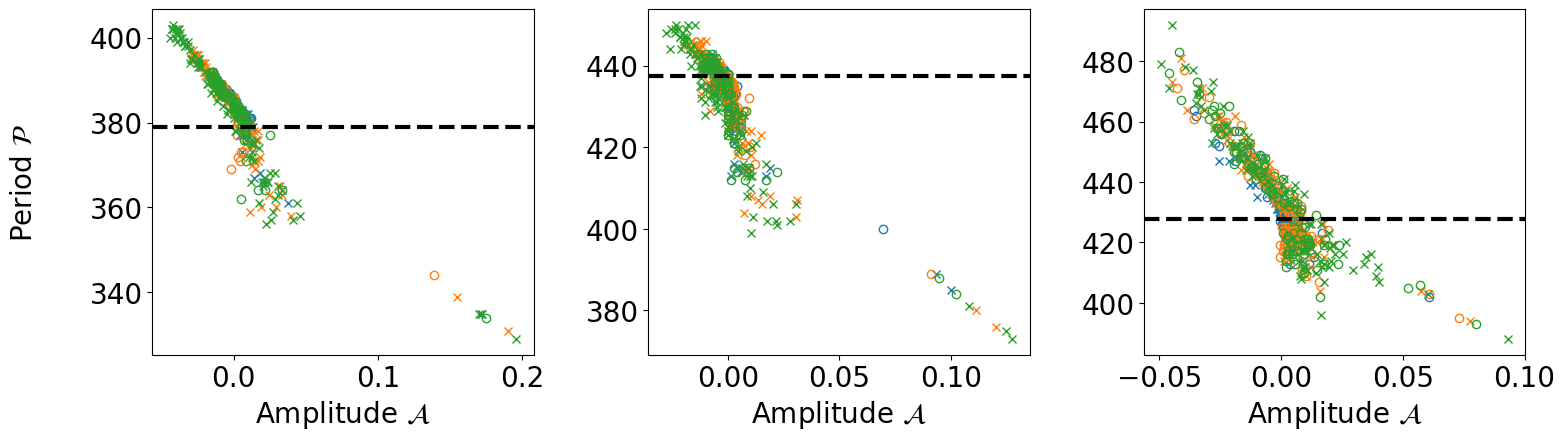

In [22]:
xlabel = r"Amplitude $\mathcal{A}$"
ylabel = [r"Period $\mathcal{P}$"]

#### cost comb // point // weight // n

colmap = mpl.cm.get_cmap('tab10')
marker= ["o", "x"]
mew = 1

x_array = peak_times[0,:]

fig, ax = plt.subplots(1, 3, figsize=(fig_width,0.25*fig_width))#, sharex="col")

for wi in range(3):
    ax[0].plot(amplitude[0, 2, wi, :], period_all[0, 2, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 2, ", wi, scipy.stats.pearsonr(amplitude[0, 2, wi, :], period_all[0, 2, wi, :], method=method).pvalue)
    ax[0].plot(amplitude[2, 2, wi, :], period_all[2, 2, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 2, ", wi, scipy.stats.pearsonr(amplitude[2, 2, wi, :], period_all[2, 2, wi, :], method=method).pvalue)

    ax[1].plot(amplitude[0, 0, wi, :], period_all[0, 0, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 0, ", wi, scipy.stats.pearsonr(amplitude[0, 0, wi, :], period_all[0, 0, wi, :], method=method).pvalue)
    ax[1].plot(amplitude[2, 0, wi, :], period_all[2, 0, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 0, ", wi, scipy.stats.pearsonr(amplitude[2, 0, wi, :], period_all[2, 0, wi, :], method=method).pvalue)

    ax[2].plot(amplitude[0, 1, wi, :], period_all[0, 1, wi, :], marker=marker[0], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("0, 1, ", wi, scipy.stats.pearsonr(amplitude[0, 1, wi, :], period_all[0, 1, wi, :], method=method).pvalue)
    ax[2].plot(amplitude[2, 1, wi, :], period_all[2, 1, wi, :], marker=marker[1], markerfacecolor="none", markeredgewidth=mew, color=colmap(wi*0.1), linestyle="none")
    #print("2, 1, ", wi, scipy.stats.pearsonr(amplitude[2, 1, wi, :], period_all[2, 1, wi, :], method=method).pvalue)

ax[0].set_ylabel(ylabel[0])

#ax[0].set_xlim([-0.08, 0.17])
#ax[1].set_xlim([-0.04, 0.05])
#ax[2].set_xlim([-0.05, 0.05])

#ax[0].set_ylim([350,415])
#ax[1].set_ylim([405,460])

ax[0].axhline(y=period_a, color='k', linestyle="--")
ax[1].axhline(y=period_b, color='k', linestyle="--")
ax[2].axhline(y=period_c, color='k', linestyle="--")

for ix in range(3):
    ax[ix].set_xlabel(xlabel)

ax[0].yaxis.set_label_coords(-0.3,0.5)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.3, hspace=0.1)
plt.savefig(os.path.join(datadir, "period_amp.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [12]:
with open(os.path.join(datadir, 'prc.pickle'), 'rb') as f:
    data_read = pickle.load(f)
[prc_A, prc_B] = data_read

prc_A /= len(prc_A)
prc_B /= len(prc_B)

dt_ = 0.001

time_A = np.arange(0,len(prc_A)*dt_, dt_)
prc_B = norm_time(prc_B, time_A)

prc_A *= -1./(2.*0.01)
prc_B *= -1./(2.*0.01) ## width = 2, amp = 0.01

/tmp/ipykernel_132465/3956244990.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' 

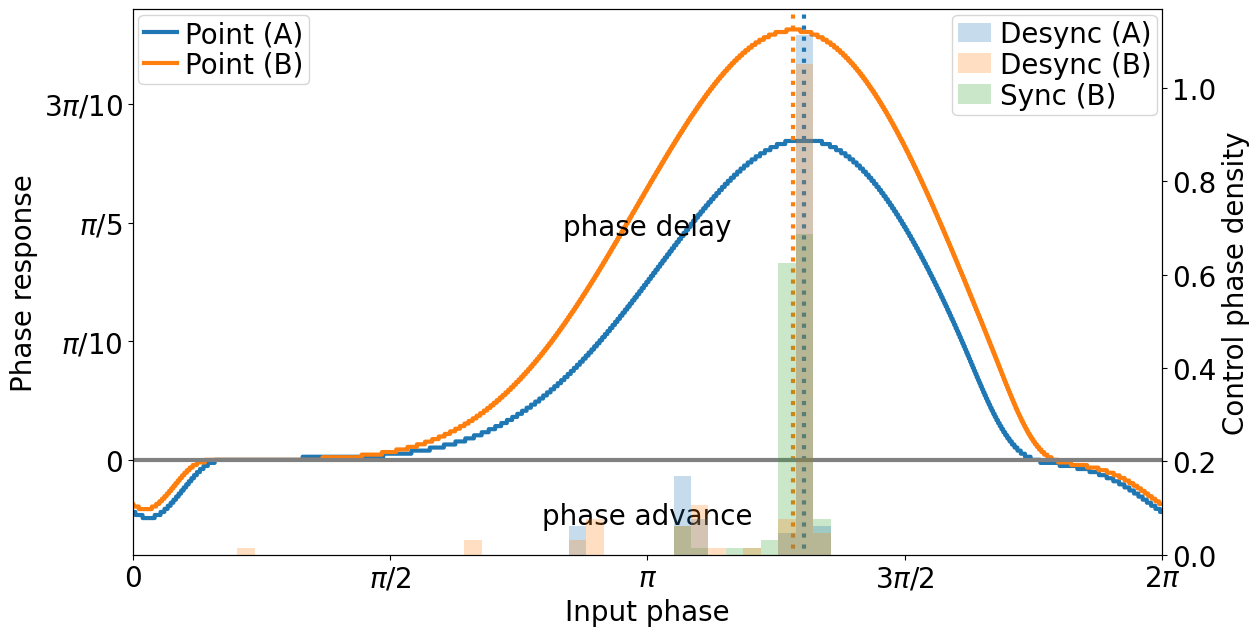

1.3033185154553912 1.283572831593094


In [13]:
colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,1, figsize=(0.75*fig_width,0.4*fig_width))

ax.plot(time_A, prc_A, color=colmap(0.), label="Point (A)")
ax.plot(time_A, prc_B, color=colmap(0.1), label="Point (B)")

# wide minimum, get argmin from both sides
argmin0, argmin1 = np.argmax(prc_A), np.argmax(prc_A[::-1])
argmin_A = np.mean([argmin0, len(prc_A)-argmin1])
argmin0, argmin1 = np.argmax(prc_B), np.argmax(prc_B[::-1])
argmin_B = np.mean([argmin0, len(prc_B)-argmin1])

ax.vlines(dt_*argmin_A, -1, 1, color=colmap(0), linestyle=":")
ax.vlines(dt_*argmin_B, -1, 1, color=colmap(0.1), linestyle=":")
ax.hlines(0, -0.1, 700., color="gray")

ax.set_xlim(0,len(time_A)*dt_)
ax.set_xticks([0, 0.25*(len(time_A)*dt_), 0.5*(len(time_A)*dt_), 0.75*(len(time_A)*dt_), (len(time_A)*dt_)])
ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

ax.set_yticks([ 0, 0.05, 0.1, 0.15])
ax.set_ylim(-0.04, 0.19)
ax.set_yticklabels(["0", r"$\pi/10$", r"$\pi/5$", r"$3\pi/10$"])

ax.text(0.5, 0.07, "phase advance", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
ax.text(0.5, 0.6, "phase delay", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

ax.legend(loc="upper right")
ax.set_xlabel("Input phase")
ax.set_ylabel("Phase response")

ax2 = ax.twinx()
nbins = 60
st = np.concatenate( (phases[0, 2, :, :, 0], phases[2, 2, :, :, 0]), axis=0)
ax2 = sns.histplot(len(time_A)*dt_*np.mean(st, axis=0)/(2.*np.pi), bins=len(time_A)*dt_*np.linspace(0.0, 1., nbins), stat="density", color = colmap(0.), edgecolor="none", alpha=0.25, label="Desync (A)")
st = np.concatenate( (phases[0, 0, :, :, 0], phases[2, 0, :, :, 0]), axis=0)
ax2 = sns.histplot(len(time_A)*dt_*np.mean(st, axis=0)/(2.*np.pi), bins=len(time_A)*dt_*np.linspace(0.0, 1., nbins), stat="density", color = colmap(0.1), edgecolor="none", alpha=0.25, label="Desync (B)")
st = np.concatenate( (phases[0, 1, :, :, 0], phases[2, 1, :, :, 0]), axis=0)
ax2 = sns.histplot(len(time_A)*dt_*np.mean(st, axis=0)/(2.*np.pi), bins=len(time_A)*dt_*np.linspace(0.0, 1., nbins), stat="density", color = colmap(0.2), edgecolor="none", alpha=0.25, zorder=-10, label="Sync (B)")

ax2.set_ylabel("Control phase density")

ax.legend(loc="upper left", labelspacing=0.1, handlelength=1.2, handletextpad=0.3, borderpad=0.2, borderaxespad=0.2)
ax2.legend(loc="upper right", labelspacing=0.1, handlelength=1.2, handletextpad=0.3, borderpad=0.2, borderaxespad=0.2)
plt.savefig(os.path.join(datadir, "prc.jpg"), bbox_inches='tight', dpi=300)
plt.show()

argmin_A *=(2.*np.pi)/(len(time_A))
argmin_B *=(2.*np.pi)/(len(time_A))

print(argmin_A/(np.pi), argmin_B/(np.pi))

In [34]:
x_array = [av_c, wnd]#, coord_data[:,0], coord_data[:,1], coord_data[:,2], r_coord]
xlabel = ["Average controllability", "Weighted node degree"]#, "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation time lag", "Period", "Control phase", "Amplitude", "Energy"]

wi = 1
y_array = [peak_times, period_all, phases[:,:,:,:,0], amplitude, energy]

r_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
p_mat_sc_cd = np.zeros((len(x_array), len(y_array)))
tot_count_mat = np.zeros((len(x_array), len(y_array)))

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for task in [0,2]:
            for point in [2,0]:
                for wi in range(3):

                    y_arr = y[task, point, wi, :].copy()

                    if iy in [2,3]:
                        y_arr /= np.mean(np.abs(y_arr))

                    #for n in range(N-1, -1, -1):
                        #if np.isnan(y_arr[task, point, wi, n]):
                        #    x_arr = np.delete(x_arr, n, 0)
                        #    y_arr = np.delete(y_arr, n, 3)

                    result = scipy.stats.pearsonr(x, y_arr, method=method)
                    r_val = result.statistic
                    p_val = result.pvalue
                    tot_count_mat[ix,iy] += 1
                    if p_val < 0.05:
                        r_mat_sc_cd[ix, iy] += r_val
                        p_mat_sc_cd[ix, iy] += 1

Average controllability Oscillation time lag
Average controllability Period
Average controllability Control phase
Average controllability Amplitude
Average controllability Energy
Weighted node degree Oscillation time lag
Weighted node degree Period
Weighted node degree Control phase
Weighted node degree Amplitude
Weighted node degree Energy


In [35]:
print(tot_count_mat)

[[12. 12. 12. 12. 12.]
 [12. 12. 12. 12. 12.]]


[12. 12.  2. 12. 10.]
[12. 12. 12. 12. 12.]
nonsignificant
nonsignificant


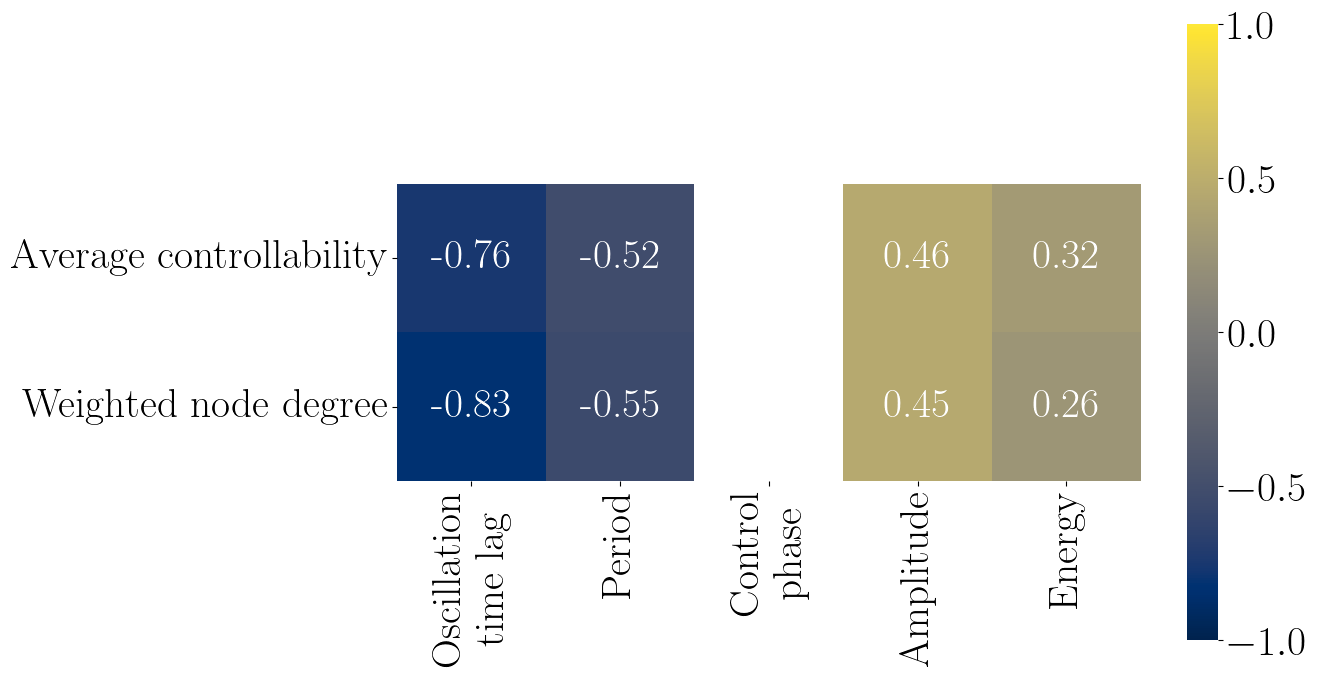

In [36]:
xlabel = ["Average controllability", "Weighted node degree"]#, "x coordinate", "y coordinate", "z coordinate", "r coordinate"]
ylabel = ["Oscillation\n time lag", "Period", "Control\n phase", "Amplitude", "Energy"]

annotations = r_mat_sc_cd.copy()

print(p_mat_sc_cd[1,:])
print(tot_count_mat[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd[ix, iy]/float(tot_count_mat[ix,iy]) <=0.5:
            print("nonsignificant")
            annotations[ix, iy] = None
        else:
            annotations[ix,iy] /= p_mat_sc_cd[ix, iy]

plt.figure(figsize=(12,8))
ax = sns.heatmap(annotations, annot=True, fmt='.2f', cmap=cmap, yticklabels=xlabel, xticklabels=ylabel, vmin=-1, vmax=1)#, annot_kws={"fontweight":"bold"})
#for ind in [[0,0], [2,0], [0,1], [1,1], [2,1], [0,5]]:
#    rect = plt.Rectangle(ind, 1,1, color="red", linewidth=3, fill=False, clip_on=False)
#    ax.add_patch(rect)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90)
plt.yticks(rotation=0) 

plt.savefig(os.path.join(datadir, "sc_cd_desync.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [37]:
y_array = [peak_times, period_all, phases[:,:,:,:,0], input, energy]

r_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array), 3))
p_mat_sc_cd_sync = np.zeros((len(x_array), len(y_array)))
tot_count_mat_sync = np.zeros((len(x_array), len(y_array)))

task, point = 0, 1

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for wi in range(3):

            y_arr = y[task, point, wi, :].copy()

            if iy in [2,3]:
                y_arr /= np.mean(np.abs(y_arr))

            result = scipy.stats.pearsonr(x, y_arr, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            tot_count_mat_sync[ix,iy] += 1
            if p_val < 0.05:
                r_mat_sc_cd_sync[ix, iy, wi] += r_val
                p_mat_sc_cd_sync[ix, iy] += 1

for ix in range(len(x_array)):
    for iy in range(len(y_array)):
        if np.abs(np.mean(r_mat_sc_cd_sync[ix,iy,:])) < 1e-8:
            p_mat_sc_cd_sync[ix, iy] = 0
        elif np.std(r_mat_sc_cd_sync[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync[ix,iy,:])) > 0.333:
            print("large deviation ", ix, iy)
            p_mat_sc_cd_sync[ix, iy] = 0

Average controllability Oscillation
 time lag
Average controllability Period
Average controllability Control
 phase
Average controllability Amplitude
Average controllability Energy
Weighted node degree Oscillation
 time lag
Weighted node degree Period
Weighted node degree Control
 phase
Weighted node degree Amplitude
Weighted node degree Energy
large deviation  1 1
large deviation  1 3


In [38]:
y_array = [peak_times, period_all, phases[:,:,:,:,0], input, energy]

r_mat_sc_cd_sync_cc = np.zeros((len(x_array), len(y_array), 3))
p_mat_sc_cd_sync_cc = np.zeros((len(x_array), len(y_array)))
tot_count_mat_sync_cc = np.zeros((len(x_array), len(y_array)))

task, point = 2, 1

for ix, x in enumerate(x_array):
    for iy, y in enumerate(y_array):

        print(xlabel[ix], ylabel[iy])

        result = 0. 
        count_total = 0

        for wi in range(3):

            y_arr = y[task, point, wi, :].copy()

            if iy in [2,3]:
                y_arr /= np.mean(np.abs(y_arr))

            result = scipy.stats.pearsonr(x, y_arr, method=method)
            r_val = result.statistic
            p_val = result.pvalue
            tot_count_mat_sync_cc[ix,iy] += 1
            if p_val < 0.05:
                r_mat_sc_cd_sync_cc[ix, iy, wi] += r_val
                p_mat_sc_cd_sync_cc[ix, iy] += 1

for ix in range(len(x_array)):
    for iy in range(len(y_array)):
        if np.abs(np.mean(r_mat_sc_cd_sync_cc[ix,iy,:])) < 1e-8:
            p_mat_sc_cd_sync[ix, iy] = 0
        elif np.std(r_mat_sc_cd_sync_cc[ix,iy,:])/ np.abs(np.mean(r_mat_sc_cd_sync_cc[ix,iy,:])) > 0.333:
            print("large deviation ", ix, iy)
            p_mat_sc_cd_sync_cc[ix, iy] = 0

Average controllability Oscillation
 time lag
Average controllability Period
Average controllability Control
 phase
Average controllability Amplitude
Average controllability Energy
Weighted node degree Oscillation
 time lag
Weighted node degree Period
Weighted node degree Control
 phase
Weighted node degree Amplitude
Weighted node degree Energy
large deviation  0 3
large deviation  1 1
large deviation  1 3


[3. 0. 0. 0. 0.]
[3. 3. 3. 3. 3.]


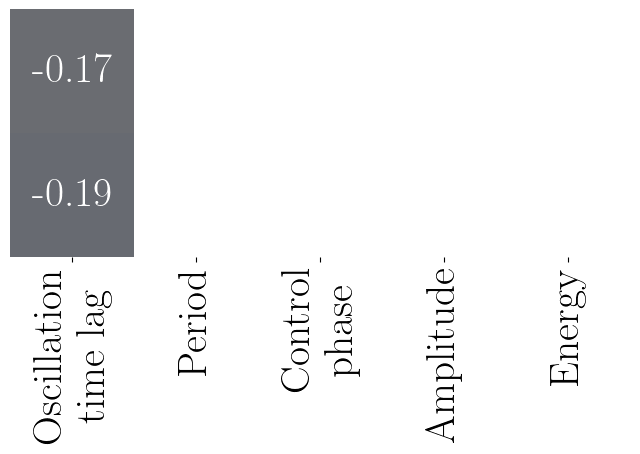

[3. 0. 0. 0. 0.]
[3. 3. 3. 3. 3.]


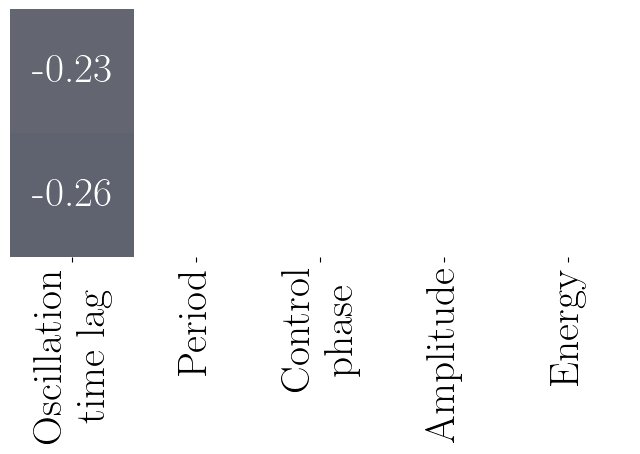

In [39]:
annotations = r_mat_sc_cd_sync.copy()

print(p_mat_sc_cd_sync[1,:])
print(tot_count_mat_sync[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd_sync[ix, iy]/float(tot_count_mat_sync[ix,iy]) <=0.5:
            annotations[ix, iy, 0] = None
        else:
            annotations[ix,iy, 0] = np.mean(r_mat_sc_cd_sync[ix, iy, :])/p_mat_sc_cd_sync[ix, iy]

plt.figure(figsize=(8,12))
ax = sns.heatmap(annotations[:,:,0], annot=True, fmt='.2f', cmap=cmap, yticklabels=False, xticklabels=ylabel, vmin=-1, vmax=1, cbar=False)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_sync_var.jpg"), bbox_inches='tight', dpi=300)
plt.show()

annotations = r_mat_sc_cd_sync_cc.copy()

print(p_mat_sc_cd_sync_cc[1,:])
print(tot_count_mat_sync_cc[1,:])

for ix, x in enumerate(xlabel):
    for iy, y in enumerate(ylabel):
        
        if p_mat_sc_cd_sync_cc[ix, iy]/float(tot_count_mat_sync_cc[ix,iy]) <=0.5:
            annotations[ix, iy, 0] = None
        else:
            annotations[ix,iy, 0] = np.mean(r_mat_sc_cd_sync_cc[ix, iy, :])/p_mat_sc_cd_sync_cc[ix, iy]

plt.figure(figsize=(8,12))
ax = sns.heatmap(annotations[:,:,0], annot=True, fmt='.2f', cmap=cmap, yticklabels=False, xticklabels=ylabel, vmin=-1, vmax=1, cbar=False)
ax.set_aspect('equal', adjustable='box')
plt.xticks(rotation=90) 
plt.savefig(os.path.join(datadir, "sc_cd_sync_cc.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [13]:
#### strongest energy input L2

nodes_0 = [[],[],[]]
nodes_2 = [[],[],[]]

for task in [0,2]:
    for point in [2,0,1]:
        impnodes = []
        for weight in range(3):
            ensort = np.argsort(energy[task, point, weight,:])[-2:]
            for e in ensort:
                impnodes.append(e)

        if task == 0:
            for i in impnodes:
                if impnodes.count(i) > 0:
                    if i not in nodes_0[point]:
                        nodes_0[point].append(i)
                
        elif task == 2:
            for i in impnodes:
                if impnodes.count(i) > 0:
                    if i not in nodes_2[point]:
                        nodes_2[point].append(i)

nodes_1 = [[],[],[]]
node1 = np.zeros((3))
nodes_3 = [[],[],[]]
node3 = np.zeros((3))

for task in [1]:
    for point in [2,0,1]:
        impnodes = []
        for weight in [0,1]:
            print("task, point, weight = ", task, point, weight)
            nodes_1[point] = [i for i,v in enumerate(energy[task, point, weight,:]) if v > 0.01]
            print("largest nodes = ", nodes_1[point])
        node1[point] = np.argmax(energy[task, point, 0,:])

for task in [3]:
    for point in [2,0,1]:
        impnodes = []
        for weight in [0,1]:
            print("task, point, weight = ", task, point, weight)
            nodes_3[point] = [i for i,v in enumerate(energy[task, point, weight,:]) if v > 0.01]
            print("largest nodes = ", nodes_3[point])
        node3[point] = np.argmax(energy[task, point, 0,:])

task, point, weight =  1 2 0
largest nodes =  [68]
task, point, weight =  1 2 1
largest nodes =  [58, 68, 70, 88]
task, point, weight =  1 0 0
largest nodes =  [36]
task, point, weight =  1 0 1
largest nodes =  [14, 36, 49, 65]
task, point, weight =  1 1 0
largest nodes =  [75]
task, point, weight =  1 1 1
largest nodes =  [17, 75, 93]
task, point, weight =  3 2 0
largest nodes =  [68]
task, point, weight =  3 2 1
largest nodes =  [14, 28, 36, 63, 68]
task, point, weight =  3 0 0
largest nodes =  [49]
task, point, weight =  3 0 1
largest nodes =  [36, 68, 70, 88]
task, point, weight =  3 1 0
largest nodes =  [17, 75, 93]
task, point, weight =  3 1 1
largest nodes =  [17, 75, 79, 93]


In [14]:
print(" ".join(str(x) for x in np.sort(nodes_0[2])))
print(" ".join(str(x) for x in np.sort(nodes_0[0])))
print(" ".join(str(x) for x in np.sort(nodes_0[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_1[2])))
print(" ".join(str(x) for x in np.sort(nodes_1[0])))
print(" ".join(str(x) for x in np.sort(nodes_1[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_2[2])))
print(" ".join(str(x) for x in np.sort(nodes_2[0])))
print(" ".join(str(x) for x in np.sort(nodes_2[1])))
print("---------------")
print(" ".join(str(x) for x in np.sort(nodes_3[2])))
print(" ".join(str(x) for x in np.sort(nodes_3[0])))
print(" ".join(str(x) for x in np.sort(nodes_3[1])))
print("---------------")

67 68 69
27 36 49 68
9 17 75
---------------
58 68 70 88
14 36 49 65
17 75 93
---------------
58 67 68 88
36 68
9 75 93
---------------
14 28 36 63 68
36 68 70 88
17 75 79 93
---------------


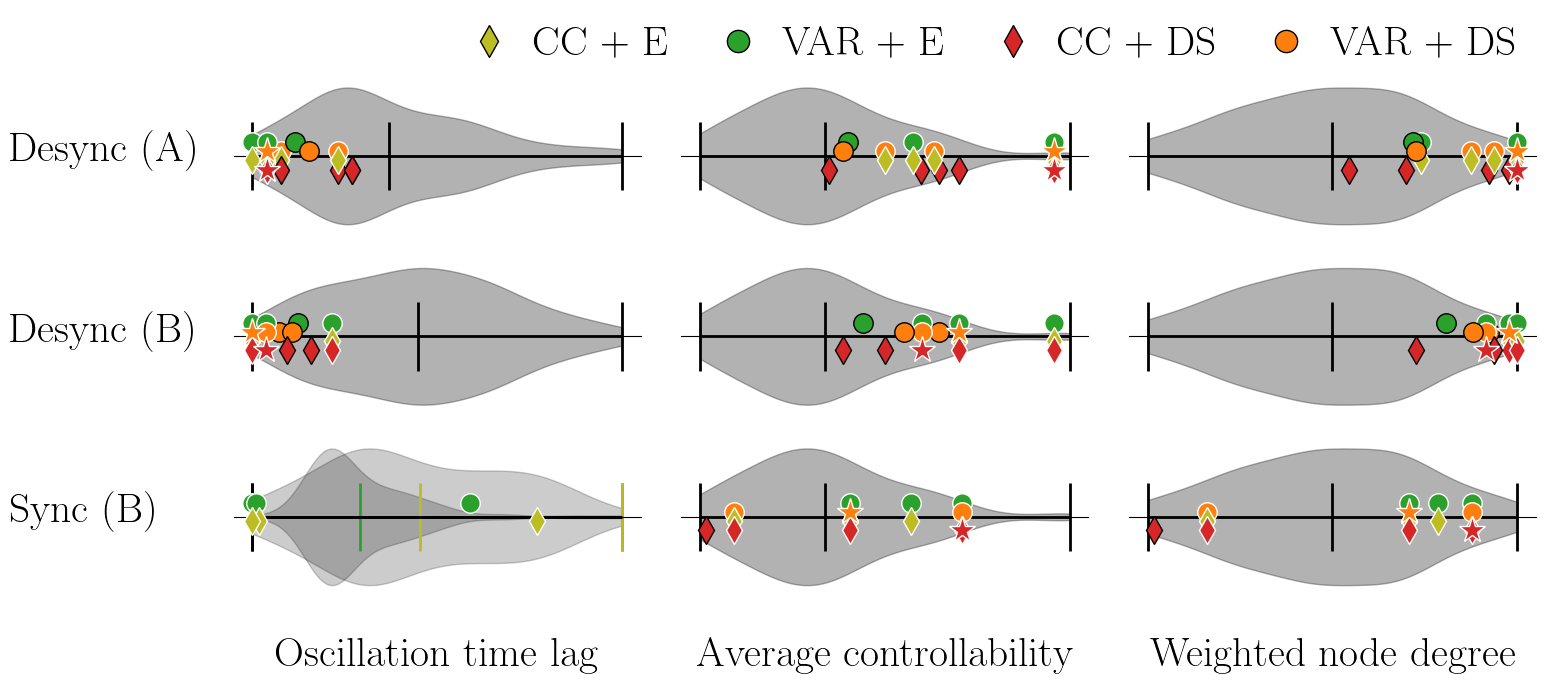

In [15]:
ylabel = ["Desync (A)", "Desync (B)", "Sync (B)"]
xlabel = ["Oscillation time lag", "Average controllability", "Weighted node degree", "Fiber length"]
colmap = mpl.colormaps["tab10"]

overlap_a = [58, 67, 68, 88]
overlap_b = [36, 49, 68]
overlap_sb = [9, 17, 75, 93]

overlap = [ overlap_b, overlap_sb, overlap_a]

msbase = 14
msscale = 0

peak_times_norm = np.zeros_like(peak_times)
for point in [0,1,2,3]:
    for task in [0,1,2]:
        for wi in [0,1,2]:
            if point in [1,3] and wi == 2: continue
            peak_times_norm[point, task, wi, :] = peak_times[point, task, wi, :] / np.amax(peak_times[point, task, wi, :])

fig, ax = plt.subplots(3, 3, figsize=(1.05*fig_width,0.37*fig_width))

for ir, task in enumerate([2,0,1]):

    for n in range(N):
        if n in nodes_0[task]:
            col = colmap(0.2)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.04
            ms = msbase + msscale * np.sqrt(np.mean(energy[0,task,:,n])/np.mean(  [np.amax(energy[0,task,0,:]), np.amax(energy[0,task,1,:]), np.amax(energy[0,task,2,:]) ]))
            ax[ir,0].plot(peak_times_norm[0,task,0,n], shift, marker="o", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n == node1[task]:
            col = colmap(0.1)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.0133
            ms = 20
            if ir != 2:
                ax[ir,0].plot(peak_times_norm[1,task,0,n], shift, marker="*", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=20)
            ax[ir,1].plot(av_c[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,2].plot(wnd[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
        if n in nodes_1[task] and n != node1[task]:
            col = colmap(0.1)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = 0.0133
            ms =  msbase + msscale * np.sqrt(energy[1,task,1,n]/np.amax(energy[1,task,1,:]))
            if ir != 2:
                ax[ir,0].plot(peak_times_norm[1,task,0,n], shift, marker="o", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="o", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n in nodes_2[task]:
            col = colmap(0.8)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.0133
            ms =  msbase + msscale * np.sqrt(np.mean(energy[2,task,:,n])/np.mean(  [np.amax(energy[2,task,0,:]), np.amax(energy[2,task,1,:]), np.amax(energy[2,task,2,:]) ]))
            ax[ir,0].plot(peak_times_norm[2,task,0,n], shift, marker="d", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        if n == node3[task]:
            col = colmap(0.3)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.04
            ms = 20
            if ir != 2:
                ax[ir,0].plot(peak_times_norm[3,task,0,n], shift, marker="*", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=20)
            ax[ir,1].plot(av_c[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
            ax[ir,2].plot(wnd[n], shift, marker="*", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=20)
        if n in nodes_3[task] and n != node3[ir]:
            col = colmap(0.3)
            edcol = "k"
            if n in overlap[task]: edcol ="white"
            shift = -0.04
            ms =  msbase + msscale * np.sqrt(energy[3,task,1,n]/np.amax(energy[3,task,1,:]))
            if ir != 2:
                ax[ir,0].plot(peak_times_norm[3,task,0,n], shift, marker="d", markeredgecolor=edcol, markersize=ms, linestyle="none", color=col, zorder=10)
            ax[ir,1].plot(av_c[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
            ax[ir,2].plot(wnd[n], shift, marker="d", markeredgecolor=edcol, markersize=ms,  linestyle="none", color=col, zorder=10)
        #else:
        #    ax[ir,0].plot(peak_times_norm[0,ir,2,n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,1].plot(av_c[n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,2].plot(wnd[n], 0, marker="x", linestyle="none", color="k")
        #    ax[ir,3].plot(nfl[n], 0, marker="x", linestyle="none", color="k")

    if ir == 2:
        p00 = ax[ir,0].violinplot(peak_times_norm[0,task,2,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        #p01 = ax[ir,0].violinplot(peak_times_norm[1,task,0,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        p02 = ax[ir,0].violinplot(peak_times_norm[2,task,0,:], positions=-0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
        #p03 = ax[ir,0].violinplot(peak_times_norm[3,task,0,:], positions=0.0 * np.ones((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    else:
        p0 = ax[ir,0].violinplot(peak_times_norm[0,task,0,:], positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    p1 = ax[ir,1].violinplot(av_c, positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)
    p2 = ax[ir,2].violinplot(wnd, positions=np.zeros((1)), vert=False, widths=0.4, showmeans=True, showextrema=True)

    if ir == 2:
        for p in [p00, p02]: #p01, p02, p03]:
            for bod in p['bodies']:
                bod.set_facecolor('k')
                bod.set_edgecolor('k')
                bod.set_alpha(0.2)
                
            p['cbars'].set_color('k')
            p['cmins'].set_color('k')
            p['cmaxes'].set_color('k')
        p00['cmeans'].set_color(colmap(0.2))
        p00['cmaxes'].set_color(colmap(0.2))
        #p01['cmeans'].set_color(colmap(0.333))
        #p01['cmaxes'].set_color(colmap(0.333))
        p02['cmeans'].set_color(colmap(0.8))
        p02['cmaxes'].set_color(colmap(0.8))
        #p03['cmeans'].set_color(colmap(0.95))
        #p03['cmaxes'].set_color(colmap(0.95))
    else:
        for bod in p0['bodies']:
            bod.set_facecolor('k')
            bod.set_edgecolor('k')
            bod.set_alpha(0.3)
        p0['cmeans'].set_color('k')
        p0['cmaxes'].set_color('k')
        p0['cmins'].set_color('k')
        p0['cbars'].set_color('k')      

    for p in [p1, p2]:
        for bod in p['bodies']:
            bod.set_facecolor('k')
            bod.set_edgecolor('k')
            bod.set_alpha(0.3)
        
        p['cmaxes'].set_color('k')
        p['cmins'].set_color('k')
        p['cmeans'].set_color('k')
        p['cbars'].set_color('k')        

    x_ = [np.amin(peak_times_norm[1,task,0,n]), np.amax(peak_times_norm[1,task,0,:])]
    #ax[ir,0].set_xlim(x_)
    ax[ir,0].set_xticks([])
    
    x_ = [np.amin(av_c), np.amax(av_c)]
    #ax[ir,1].set_xlim(x_)
    ax[ir,1].set_xticks([])

    x_ = [np.amin(wnd), np.amax(wnd)]
    #ax[ir,2].set_xlim(x_)
    ax[ir,2].set_xticks([])

    for k in range(3):
        ax[ir,k].set_yticks([])
        #ax[ir,k].set_ylim(-0.1,0.1)

        ax[ir,k].spines['right'].set_visible(False)
        ax[ir,k].spines['left'].set_visible(False)
        ax[ir,k].spines['top'].set_visible(False)
        ax[ir,k].spines['bottom'].set_position('zero')

    ax[ir,0].set_ylabel(ylabel[ir], rotation=0, horizontalalignment="left")
    ax[ir,0].yaxis.set_label_coords(-0.55, 0.4)

for ic in range(3):
    ax[2,ic].set_xlabel(xlabel[ic])
    ax[2,ic].xaxis.set_label_coords(0.5, -0.3)

fig.align_ylabels([ax[:,0]])

legend_elements = [Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.8), marker="d", markeredgecolor="k", markersize=16, label='CC + E'),
                    Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.2), marker="o", markeredgecolor="k", markersize=16, label='VAR + E'),
                    Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.3), marker="d", markeredgecolor="k", markersize=16, label='CC + DS'),
                    Line2D([0], [0], linestyle="none", markerfacecolor=colmap(0.1), marker="o", markeredgecolor="k", markersize=16, label='VAR + DS'),
                   
                   ]

fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0.92, 0.81, .1), labelspacing=0.1, handlelength=0.1, handletextpad=1, frameon=False, ncol=4, columnspacing=1.6)

#fig.legend(handles=legend_elements, loc='upper right')

fig.subplots_adjust(left=0.2, bottom=0.1, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(os.path.join(datadir, "role_nodes_conn.jpg"), bbox_inches='tight', dpi=300, transparent=True)
plt.show()

0 2
1 0
2 1


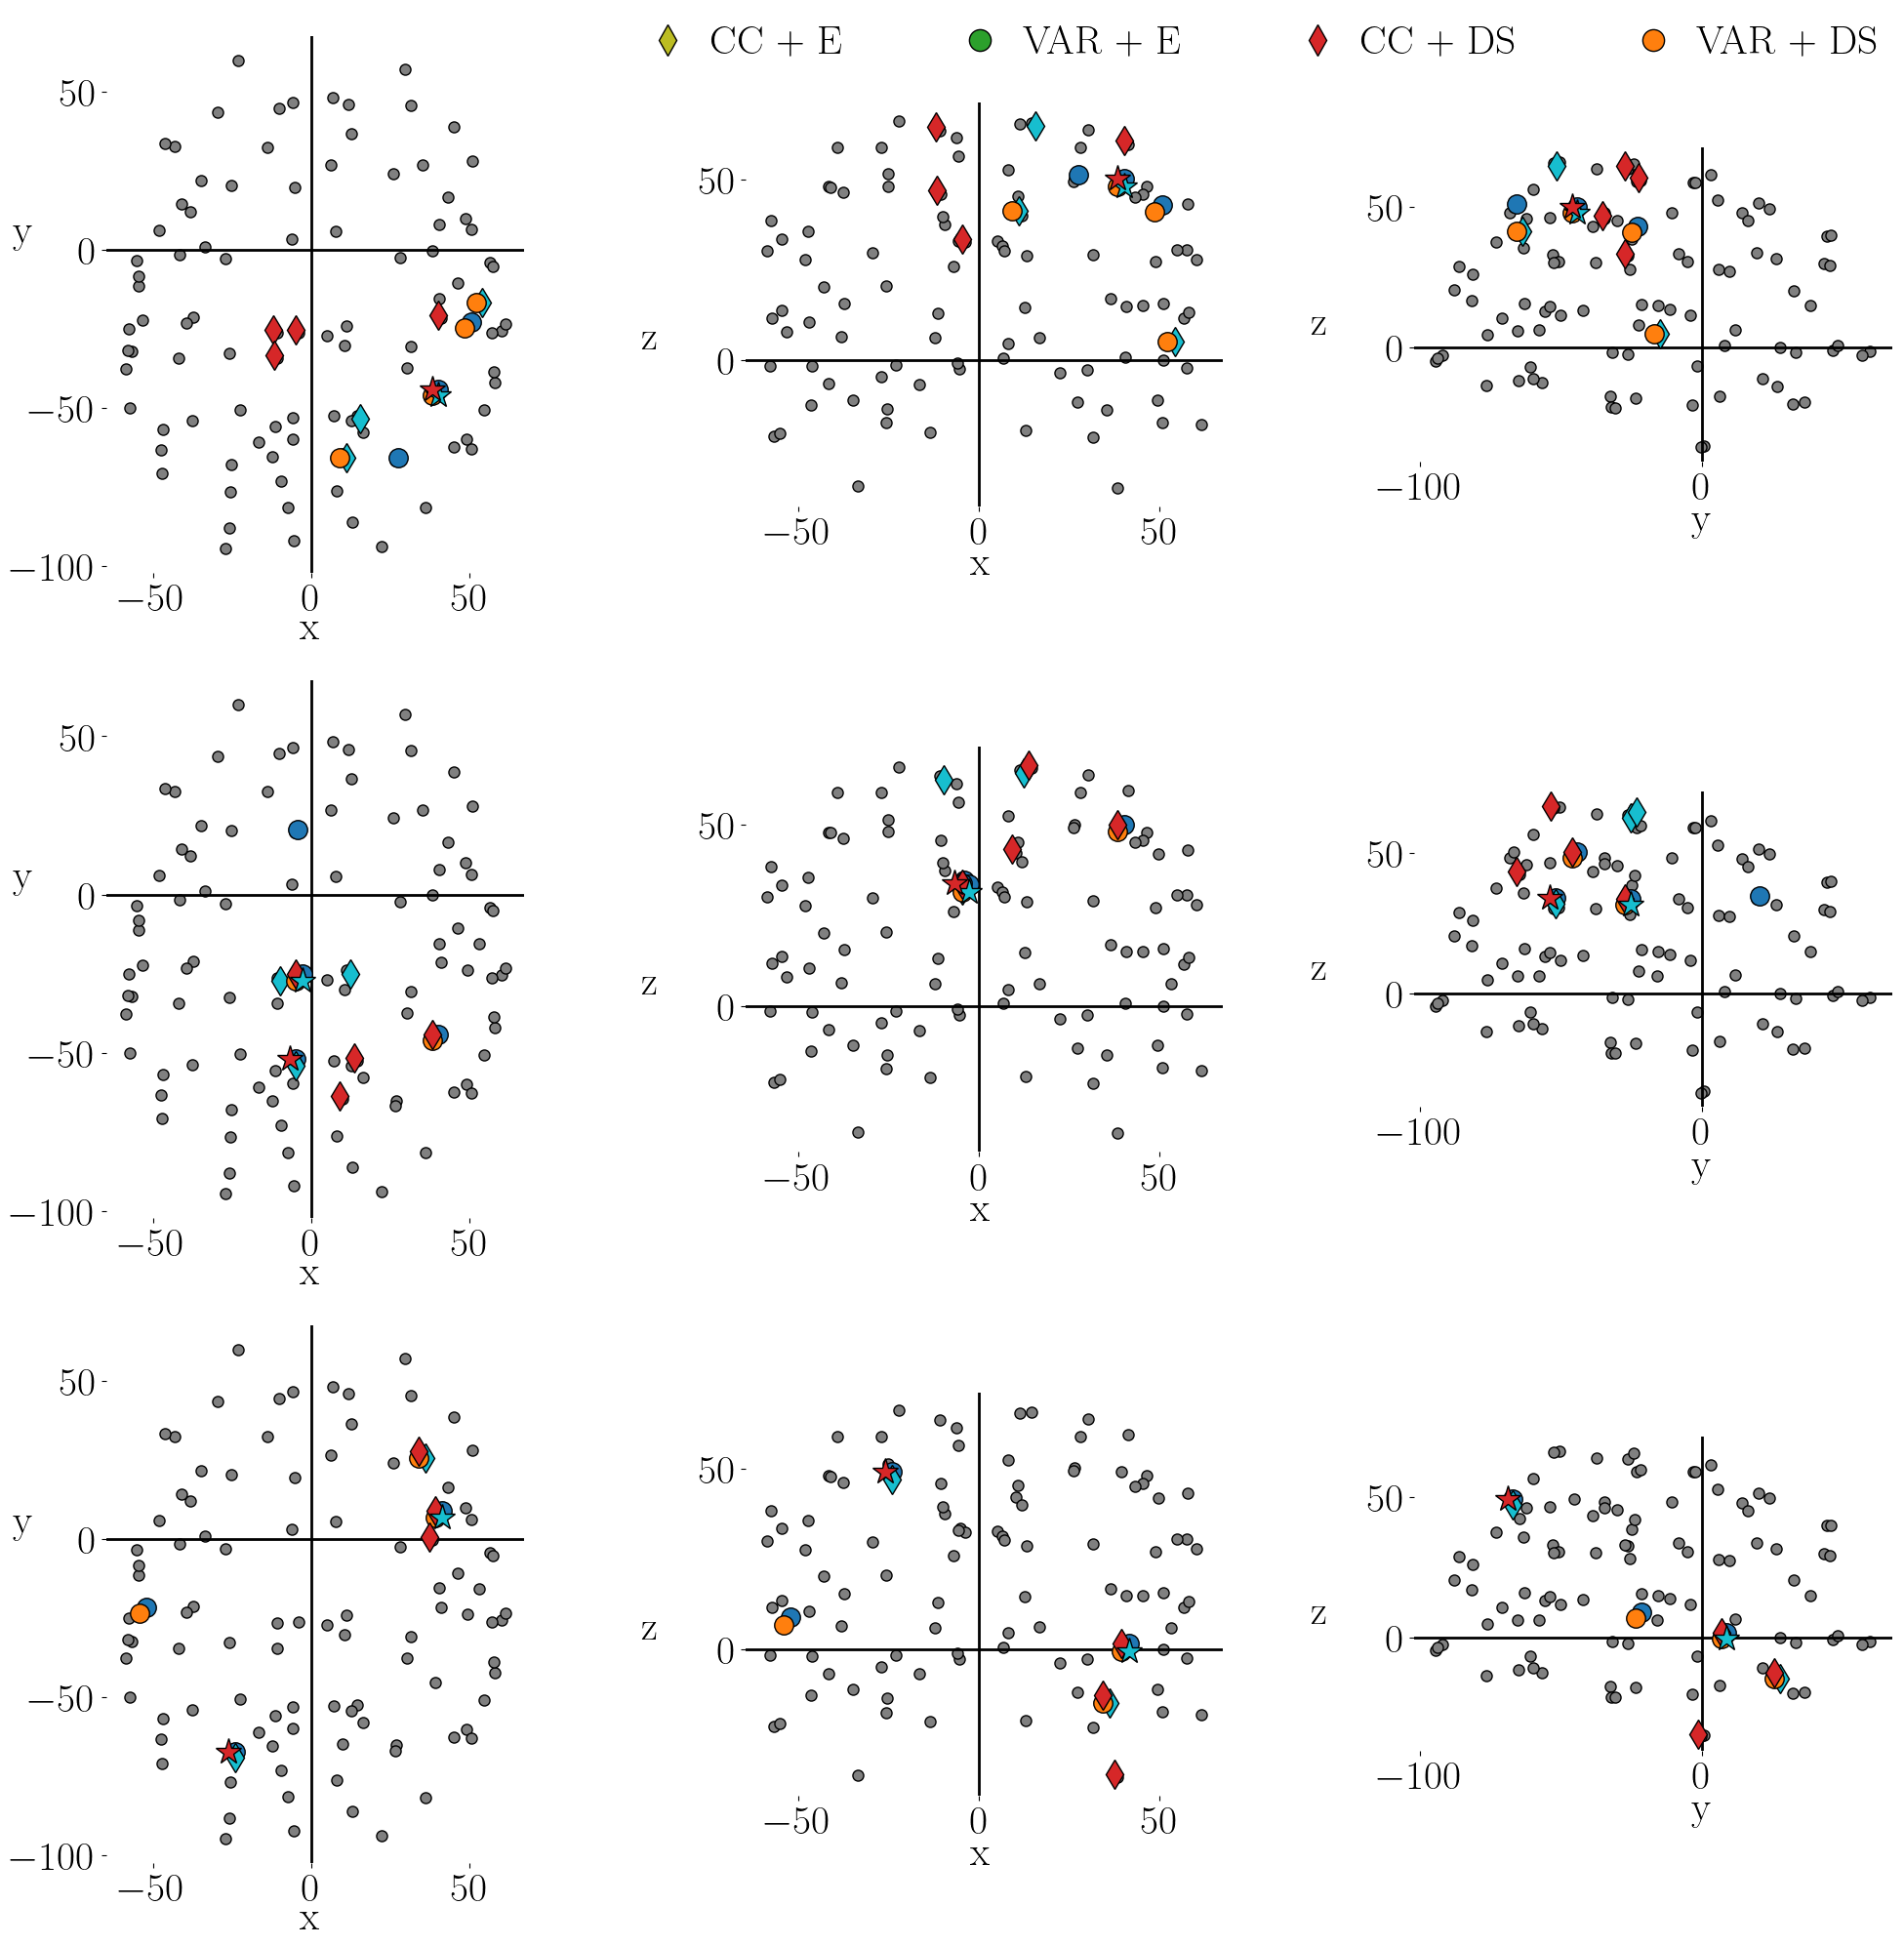

In [16]:
task = 0
point = 0
weight = 0

fig, ax = plt.subplots(3, 3, figsize=(24,24))

maxen = np.amax(energy[task,point,weight,:])
ms = 14
shift = 1.

for ip, task in enumerate([2,0,1]):
    print(ip, task)

    for n in range(N):
        if n in nodes_0[task]:
            col = colmap(0)
            marker_="o"
            markeredgecolor_="k"
            markersize_= msbase + msscale * np.sqrt(np.mean(energy[0,task,:,n])/np.mean(  [np.amax(energy[0,task,0,:]), np.amax(energy[0,task,1,:]), np.amax(energy[0,task,2,:]) ]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n == node1[task]:
            col = colmap(0.9)
            marker_="*"
            markeredgecolor_="k"
            markersize_= 20
            zorder_=20
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


        elif n in nodes_1[task]:
            col = colmap(0.9)
            marker_="d"
            markeredgecolor_="k"
            markersize_= 1 + msbase + msscale * np.sqrt(energy[1,task,1,n]/np.amax(energy[1,task,1,:]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]+shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]+shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n in nodes_2[task]:
            col = colmap(0.1)
            marker_="o"
            markeredgecolor_="k"
            markersize_= msbase + msscale * np.sqrt(np.mean(energy[2,task,:,n])/np.mean(  [np.amax(energy[2,task,0,:]), np.amax(energy[2,task,1,:]), np.amax(energy[2,task,2,:]) ]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]-shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)

    for n in range(N):
        if n == node3[task]:
            col = colmap(0.3)
            marker_="*"
            markeredgecolor_="k"
            markersize_= 20
            zorder_=20
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


        elif n in nodes_3[task]:
            col = colmap(0.3)
            marker_="d"
            markeredgecolor_="k"
            markersize_= 1 + msbase + msscale * np.sqrt(energy[3,task,1,n]/np.amax(energy[3,task,1,:]))
            zorder_=10
            ax[ip,0].plot(coord_data[n,0]-shift, coord_data[n,1]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,1].plot(coord_data[n,0]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
            ax[ip,2].plot(coord_data[n,1]-shift, coord_data[n,2]+shift, marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


for ip, point in enumerate([2,0,1]):
    for n in range(N):

        col = 'gray'
        marker_="o"
        zorder_=-10
        markersize_ = 8
        
        ax[ip,0].plot(coord_data[n,0], coord_data[n,1], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
        ax[ip,1].plot(coord_data[n,0], coord_data[n,2], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)
        ax[ip,2].plot(coord_data[n,1], coord_data[n,2], marker=marker_, color=col, markeredgecolor=markeredgecolor_, markersize=markersize_, zorder=zorder_)


    for k in range(3):
        ax[ip, k].set_aspect('equal', adjustable='box')
        ax[ip, k].axhline(y=0, color='k')
        ax[ip, k].axvline(x=0, color='k')

        #ax[k].get_xaxis().set_visible(False)

        ax[ip, k].spines['right'].set_visible(False)
        ax[ip, k].spines['left'].set_visible(False)
        ax[ip, k].spines['top'].set_visible(False)
        ax[ip, k].spines['bottom'].set_visible(False)

    ax[ip, 0].set_xlabel("x")
    ax[ip, 0].set_ylabel("y", rotation=0)

    ax[ip, 1].set_xlabel("x")
    ax[ip, 1].set_ylabel("z", rotation=0)

    ax[ip, 2].set_xlabel("y")
    ax[ip, 2].set_ylabel("z", rotation=0)

    ax[ip, 0].xaxis.set_label_coords(0.485, -0.07)
    ax[ip, 0].yaxis.set_label_coords(-0.2, 0.6)

    ax[ip, 1].xaxis.set_label_coords(0.49, -0.1)
    ax[ip, 1].yaxis.set_label_coords(-0.2, 0.37)

    ax[ip, 2].xaxis.set_label_coords(0.6, -0.13)
    ax[ip, 2].yaxis.set_label_coords(-0.2, 0.38)

fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0.8, 0.81, .1), labelspacing=0.1, handlelength=0.1, handletextpad=1, frameon=False, ncol=4, columnspacing=3.3)

plt.subplots_adjust(left=None, bottom=0.1, right=None, top=None, wspace=0.4, hspace=0.2)
plt.box(False)
plt.savefig(os.path.join(datadir, "brain_map.jpg"), bbox_inches='tight', dpi=300, transparent=True)

plt.show()

In [13]:
#fig, ax = plt.subplots(3,1, figsize=(24,20))

controls_desync_a = None
controls_desync_b = None
controls_sync_b = None
controls_sync_b_cc = None
controls_sync_b_var = None


for d in [d0_var_L2, d0_cc_L2]:
    indpm = int(0.5*period_b)
    print(indpm)
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(4):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_b) == type(None):
                        controls_desync_b = c_norm.copy()
                    else:
                        controls_desync_b = np.concatenate((controls_desync_b, c_norm), axis=0)

    print(controls_desync_b.shape)


for d in [d2_var_L2, d2_cc_L2]:
    indpm = int(0.5*period_a)
    print(indpm)
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(4):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_a) == type(None):
                        controls_desync_a = c_norm.copy()
                    else:
                        controls_desync_a = np.concatenate((controls_desync_a, c_norm), axis=0)

    print(controls_desync_a.shape)


#ax[0].set_title("Point (B) desync: CC + E")
#ax[0].set_ylabel("Activity")

plt.show()


for d in [d1_var_L2]:
    indpm = int(0.5*period_c)
    print(indpm)
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(4):

            for n in range(N):
                if len(scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0]) < tpind+2: continue
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][-3-tpind:-1-tpind]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b_var) == type(None):
                        controls_sync_b_var = c_norm.copy()
                    else:
                        controls_sync_b_var = np.concatenate((controls_sync_b_var, c_norm), axis=0)

    print(controls_sync_b_var.shape)

for d in [d1_cc_L2]:
    indpm = int(0.5*period_c)
    print(indpm)
    for wi in range(3):
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(4):

            for n in range(N):
                if len(scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0]) < tpind+2: continue
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][-3-tpind:-1-tpind]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b_cc) == type(None):
                        controls_sync_b_cc = c_norm.copy()
                    else:
                        controls_sync_b_cc = np.concatenate((controls_sync_b_cc, c_norm), axis=0)

    print(controls_sync_b_cc.shape)

    controls_sync_b = np.concatenate((controls_sync_b_cc, controls_sync_b_var), axis=0)

218
................. 0
................. 1
................. 2
(40, 437)
218
................. 0
................. 1
................. 2
(280, 437)
189
................. 0
................. 1
................. 2
(125, 379)
189
................. 0
................. 1
................. 2
(731, 379)
213
................. 0
................. 1
................. 2
(162, 427)
213
................. 0
................. 1
................. 2
(195, 427)


/tmp/ipykernel_557033/145543597.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' 

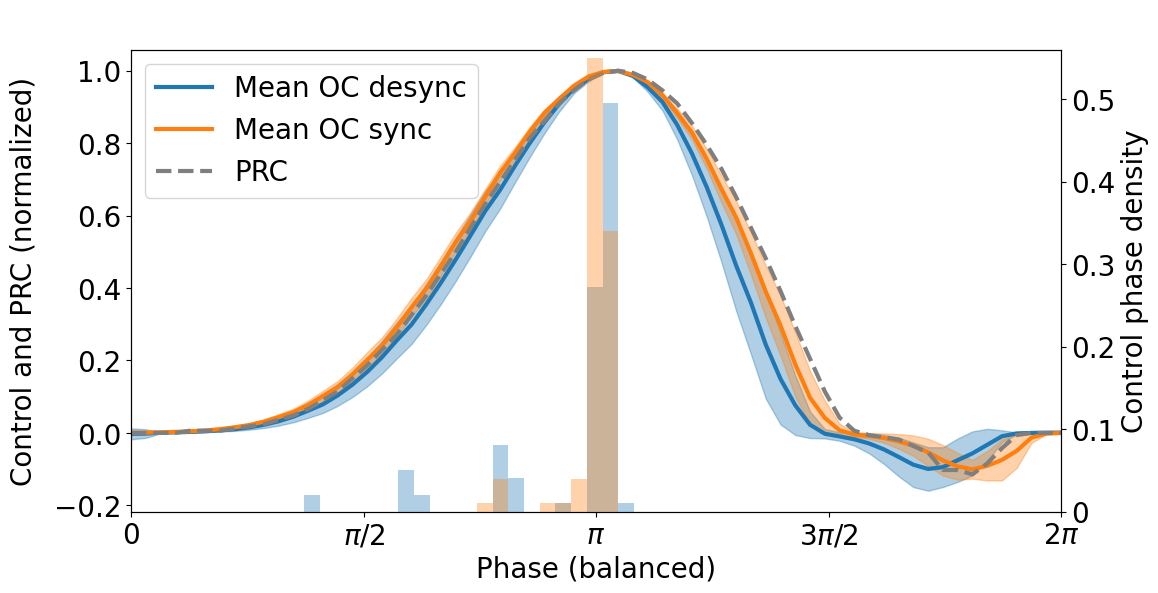

In [35]:
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 3
plt.rcParams['text.usetex'] = False

titles = ["Mean OC desync", "Mean OC sync"]
alpha = 0.35

colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,1, figsize=(12, 6), sharex=True, sharey=True)

colstep = 0.1
###############
colind = 0.0
###############
time = np.arange(0, 2.*np.pi+dt, dt)


cmean = norm_time(np.mean(controls_desync_b, axis=0), time)
cstd =  norm_time(np.std(controls_desync_b, axis=0), time)

col = colmap(colind)
ax.plot(time, cmean, color=col, label=titles[0])
ax.fill_between(time, cmean-cstd, cmean+cstd, alpha=alpha, color=col)

###############
cmean = norm_time(np.mean(controls_sync_b, axis=0), time)
cstd = norm_time(np.std(controls_sync_b, axis=0), time)

colind += colstep
col = colmap(colind)
ax.plot(time, cmean, color=col, label=titles[1])
ax.fill_between(time, cmean-cstd, cmean+cstd, alpha=alpha, color=col)

###############
indpm = int(0.5*len(time))
# 

prc_A_balanced = norm_time(prc_A, time)/np.amax(prc_A)
peakold = np.argmax(prc_A_balanced)
peaktime = np.argmax(prc_A_balanced)
prc_A_balanced = np.concatenate((prc_A_balanced, prc_A_balanced))
prc_A_balanced = prc_A_balanced[peaktime-indpm-1:peaktime+indpm-1]

prc_B_balanced = norm_time(prc_B, time)/np.amax(prc_B)
peakold = np.argmax(prc_B_balanced)
peaktime = np.argmax(prc_B_balanced)
prc_B_balanced = np.concatenate((prc_B_balanced, prc_B_balanced))
prc_B_balanced = prc_B_balanced[peaktime-indpm-1:peaktime+indpm-1]
peaknew = np.argmax(prc_B_balanced)

shift = 2. * np.pi * (peakold-peaknew) / len(time)
ax.plot(time, prc_B_balanced, color=colmap(0.7), linestyle="--", label="PRC")

ax2 = ax.twinx()
nbins = 60
st = np.mean(np.concatenate( (phases[0, 0, :, :, 0], phases[2, 0, :, :, 0]), axis=0), axis=0) - shift
ax2 = sns.histplot(st, bins=np.linspace(0.0, 2.*np.pi, nbins), stat="probability", color = colmap(0.), edgecolor="none", alpha=alpha)
st = np.concatenate( (phases[0, 1, :, :, 0], phases[2, 1, :, :, 0]), axis=0)
ax2 = sns.histplot(np.mean(st, axis=0)-shift, bins=np.linspace(0.0, 2.*np.pi, nbins), stat="probability", color = colmap(0.1), edgecolor="none", alpha=alpha)

ax.text(0.0, 1.04, r"$\overline{z} = $" + "{0:.2f}".format(0), color="white", transform=ax.transAxes)

ax2.set_ylabel("Control phase density")#, color="white")
ax2.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax2.set_yticklabels([0, 0.1, 0.2, 0.3, 0.4, 0.5])#, color="white")
ax2.set_ylim(0, 0.56)
ax.legend(loc="upper left")

#ax.set_ylim(-0.2, 1.8)
ax.set_ylabel("Control and PRC (normalized)")
ax.set_xlim(0, 2.*np.pi)
ax.set_xticks([0, 0.25*time[-1], 0.5*time[-1], 0.75*time[-1], time[-1]])
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_xlabel("Phase (balanced)")
ax.yaxis.set_label_coords(-0.1,.5)

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.0)
plt.savefig("meanOC_WB_new2.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_1702821/3337172502.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern'

189 189 189


findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not

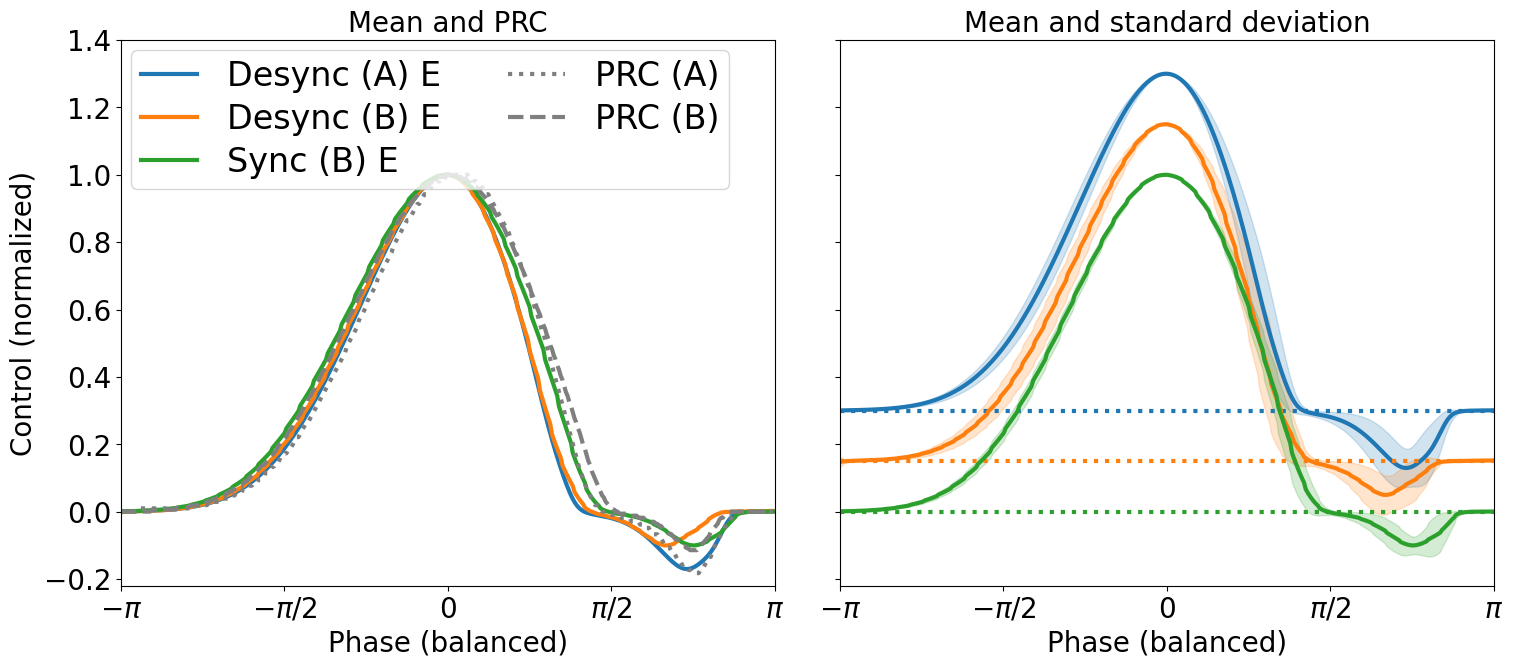

In [39]:
titles = ["Desync (A)", "Desync (B)", "Sync (B)", "Sync (B) VAR", "Sync (B) CC"]
alpha = 0.2


colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,2, figsize=(fig_width,0.4*fig_width), sharex=True, sharey=True)

ofstep = 0.15
colstep = 0.1

###############
cmean = np.mean(controls_desync_a, axis=0)
cstd = np.std(controls_desync_a, axis=0)

time = np.arange(0, len(cmean), 1)

colind = 0.0
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[0]+" E")

offset = 2. * ofstep
ax[1].plot(time, offset+cmean, color=col)
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

#cmean = np.mean(controls_desync_a_ds, axis=0)
#cstd = np.std(controls_desync_a_ds, axis=0)

#offset -= ofstep
#ax[0].plot(time, cmean, color=col, label=titles[0]+" DS", linestyle="--")
#ax[1].plot(time, offset+cmean, color=col, label=titles[0], linestyle="--")
#ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
#ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)


###############
cmean = norm_time(np.mean(controls_desync_b, axis=0), time)
cstd = norm_time(np.std(controls_desync_b, axis=0), time)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[1]+" E")

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[1])
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

#cmean = norm_time(np.mean(controls_desync_b_ds, axis=0), time)
#cstd = norm_time(np.std(controls_desync_b_ds, axis=0), time)

#offset -= ofstep
#ax[0].plot(time, cmean, color=col, label=titles[1]+" DS", linestyle="--")
#ax[1].plot(time, offset+cmean, color=col, label=titles[0], linestyle="--")
#ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
#ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = norm_time(np.mean(controls_sync_b, axis=0), time)
cstd = norm_time(np.std(controls_sync_b, axis=0), time)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[2]+" E")

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[4])
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

# cmean = norm_time(np.mean(controls_sync_b_ds, axis=0), time)
# cstd = norm_time(np.std(controls_sync_b_ds, axis=0), time)

#offset -= ofstep
# ax[0].plot(time, cmean, color=col, label=titles[2]+" DS", linestyle="--")
# ax[1].plot(time, offset+cmean, color=col, label=titles[0], linestyle="--")
# ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
# ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
indpm = int(0.5*len(time))

prc_A_balanced = norm_time(prc_A, time)/np.amax(prc_A)
peakold = np.argmax(prc_A_balanced)
peaktime = np.argmax(prc_A_balanced)
prc_A_balanced = np.concatenate((prc_A_balanced, prc_A_balanced))
prc_A_balanced = prc_A_balanced[peaktime-indpm:peaktime+indpm+1]

prc_B_balanced = norm_time(prc_B, time)/np.amax(prc_B)
peakold = np.argmax(prc_B_balanced)
peaktime = np.argmax(prc_B_balanced)
prc_B_balanced = np.concatenate((prc_B_balanced, prc_B_balanced))
prc_B_balanced = prc_B_balanced[peaktime-indpm:peaktime+indpm+1]

print(np.argmax(prc_A_balanced), np.argmax(prc_B_balanced), np.argmax(cmean))


ax[0].plot(time, prc_A_balanced/np.amax(prc_A_balanced), color=colmap(0.7), linestyle=":", label="PRC (A)")
ax[0].plot(time, prc_B_balanced/np.amax(prc_B_balanced), color=colmap(0.7), linestyle="--", label="PRC (B)")


###############
ax[0].set_title("Mean and PRC")
ax[1].set_title("Mean and standard deviation")

ax[0].legend(fontsize=24, loc="upper left", ncol=2, labelspacing=0.3, handlelength=1.7, handletextpad=0.9, borderpad=0.3, borderaxespad=0.3, columnspacing=2.0)
#ax[1].legend(loc="upper right")

ax[0].set_ylim(-0.22, 1.4)
#ax[1].set_ylim(-0.5, 1.1)

ax[0].set_ylabel("Control (normalized)")

ax[0].set_xlim(0, len(time))
ax[0].set_xticks([0, 0.25*len(time), 0.5*len(time), 0.75*len(time), len(time)])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[0].set_xlabel("Phase (balanced)")
ax[1].set_xlabel("Phase (balanced)")

ax[0].set_xlim([0, len(time*dt)])

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.0)
plt.savefig(os.path.join(datadir, "meanOC.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [40]:
#fig, ax = plt.subplots(3,1, figsize=(24,20))

controls_desync_a_ds = None
controls_desync_b_ds = None
controls_sync_b_ds = None
controls_sync_b_cc_ds = None
controls_sync_b_var_ds = None


indpm = 260

for id, d in enumerate([d0_var_L1, d0_cc_L1]):
    indpm = int(0.5*period_b)

    if id == 0:
        wi_list = [0, 4]
    elif id == 1:
        wi_list = [3, 15]

    for wi in wi_list:
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                if id == 0:
                    if wi == wi_list[0]:
                        if n != node1[0]: continue
                    else:
                        if n not in nodes_1[0]: continue
                if id == 1:
                    if wi == wi_list[0]:
                        if n != node3[0]: continue
                    else:
                        if n not in nodes_3[0]: continue

                #if n not in [36]: continue
                
                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    if np.amax(np.abs( c_norm )) > 1.1: continue
                    
                    c_norm = c_norm[np.newaxis,:]
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_b_ds) == type(None):
                        controls_desync_b_ds = c_norm.copy()
                    else:
                        controls_desync_b_ds = np.concatenate((controls_desync_b_ds, c_norm), axis=0)

    if type(controls_desync_b_ds) != type(None): print(controls_desync_b_ds.shape)


for id, d in enumerate([d2_var_L1, d2_cc_L1]):
    indpm = int(0.5*period_a)

    if id == 0:
        wi_list = [8, 11]
    elif id == 1:
        wi_list = [3, 10]

    for wi in wi_list:
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):
                if id == 0:
                    if wi == wi_list[0]:
                        if n != node1[2]: continue
                    else:
                        if n not in nodes_1[2]: continue
                if id == 1:
                    if wi == wi_list[0]:
                        if n != node3[2]: continue
                    else:
                        if n not in nodes_3[2]: continue

                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 
                #ax[0].plot(time, state_norm[n,:])

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)
                #ax[1].plot(time, control_norm[n,:])

                inittime = tps[n,0]+100
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    print("found several peaks ", cpeaktime)
                    cpeaktime = cpeaktime[:1] #[cpeaktime[np.argmax(np.abs(d["control"][wi][n,inittime+cpeaktime]))]]
                    print(cpeaktime)
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    if np.amax(np.abs( c_norm )) > 1.1: continue
                    #ax[2].plot(c_norm[0,:])

                    if type(controls_desync_a_ds) == type(None):
                        controls_desync_a_ds = c_norm.copy()
                    else:
                        controls_desync_a_ds = np.concatenate((controls_desync_a_ds, c_norm), axis=0)

    print(controls_desync_a_ds.shape)


#ax[0].set_title("Point (B) desync: CC + E")
#ax[0].set_ylabel("Activity")

plt.show()


for d in [d1_var_L1]:
    indpm = int(0.5*period_c)
    
    wi_list = [3, 10]

    for wi in wi_list:
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(1,3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):

                if wi == wi_list[0]:
                    if n != node1[1]: continue
                else:
                    if n not in nodes_1[1]: continue

                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    if np.amax(np.abs( c_norm )) > 1.1: continue

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b_var_ds) == type(None):
                        controls_sync_b_var_ds = c_norm.copy()
                    else:
                        controls_sync_b_var_ds = np.concatenate((controls_sync_b_var_ds, c_norm), axis=0)

    print(controls_sync_b_var_ds.shape)

for d in [d1_cc_L1]:
    indpm = int(0.5*period_c)
    wi_list = [7, 70]

    for wi in wi_list:
        print(".................", wi)

        tps = np.zeros((N, 2)).astype('int')
        c_norm = np.zeros((N, 2*indpm+1))

        for tpind in range(3):

            for n in range(N):
                tps[n,:] = scipy.signal.find_peaks(d["state"][wi][n,0,:], height=0.7)[0][tpind:tpind+2]

            dur = int(np.mean(tps[:,1] - tps[:,0]))
            time = np.arange(0, (dur+1)*dt, dt)
            state_norm = np.zeros((N, len(time)))
            control_norm = np.zeros((N, len(time)))

            for n in range(N):

                if wi == wi_list[0]:
                    if n != node3[1]: continue
                else:
                    if n not in nodes_3[1]: continue

                state_norm[n, :] = norm_time(d["state"][wi][n,0,tps[n,0]:tps[n,1]+1], time) 

                control_norm[n,:] = norm_time(d["control"][wi][n,tps[n,0]:tps[n,1]+1], time)

                inittime = tps[n,0]
                cpeaktime = scipy.signal.find_peaks(np.abs(d["control"][wi][n,inittime:tps[n,1]+1]), height=0.01)[0]
                if len(cpeaktime) == 0:
                    continue
                if len(cpeaktime) > 1:
                    continue
                    
                if len(cpeaktime) == 1:

                    amp = d["control"][wi][n,inittime+cpeaktime[0]]
                    
                    c_norm = d["control"][wi][n,inittime+cpeaktime[0]-indpm:inittime+cpeaktime[0]+indpm+1] / amp
                    c_norm = c_norm[np.newaxis,:]
                    if np.amax(np.abs( c_norm )) > 1.1: continue

                    if c_norm.shape[1] != (2*indpm)+1: continue

                    if type(controls_sync_b_cc_ds) == type(None):
                        controls_sync_b_cc_ds = c_norm.copy()
                    else:
                        controls_sync_b_cc_ds = np.concatenate((controls_sync_b_cc_ds, c_norm), axis=0)

    print(controls_sync_b_cc_ds.shape)

    controls_sync_b_ds = np.concatenate((controls_sync_b_cc_ds, controls_sync_b_var_ds), axis=0)
    print(controls_sync_b_ds.shape)


................. 0
................. 4
(10, 437)
................. 3
................. 15
(19, 437)
................. 8
................. 11
(9, 379)
................. 3
................. 10
(20, 379)
................. 3
................. 10
(4, 427)
................. 7
................. 70
(5, 427)
(9, 427)


/tmp/ipykernel_1702821/1658090172.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colmap = mpl.cm.get_cmap('tab10')
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern'

189 189 189


findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not found.
findfont: Font family 'Modern' not

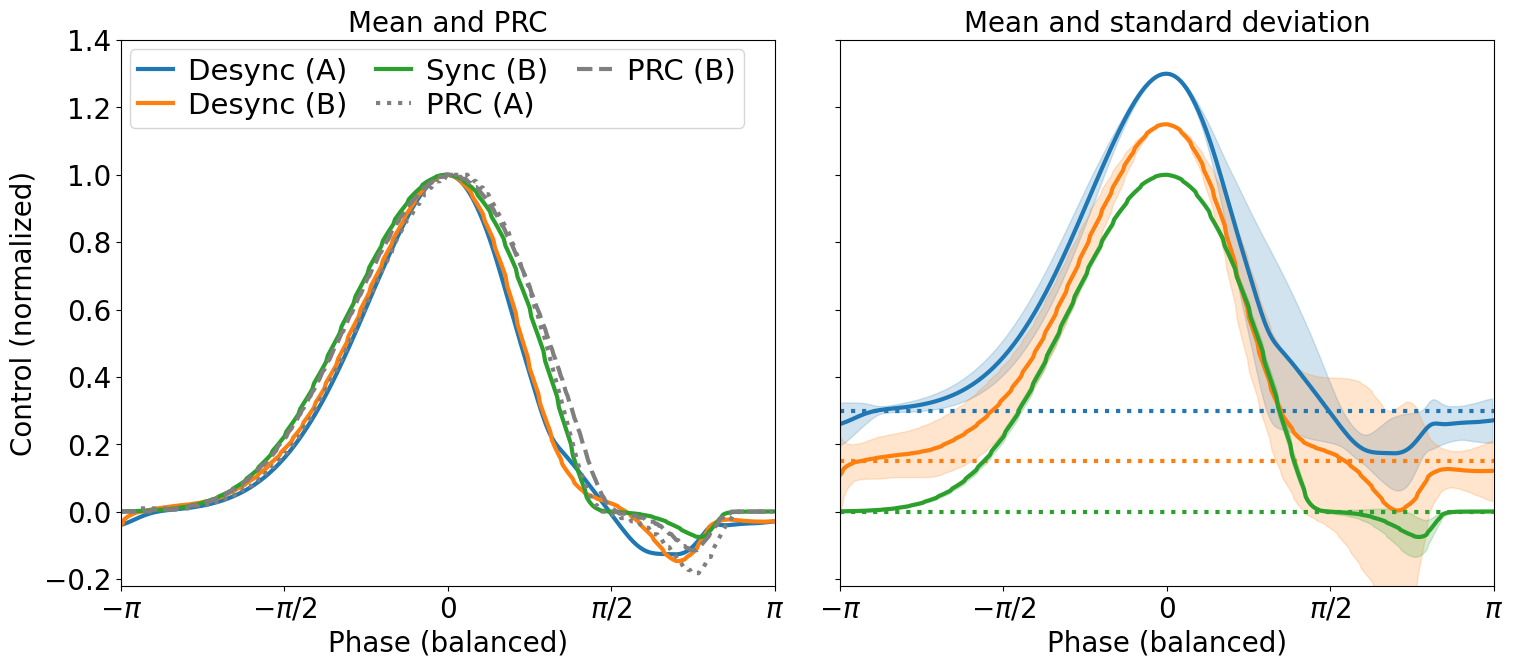

In [41]:
titles = ["Desync (A)", "Desync (B)", "Sync (B)", "Sync (B) VAR", "Sync (B) CC"]
alpha = 0.2

colmap = mpl.cm.get_cmap('tab10')
fig, ax = plt.subplots(1,2, figsize=(fig_width, 0.4*fig_width), sharex=True, sharey=True)

ofstep = 0.15
colstep = 0.1

###############
cmean = np.mean(controls_desync_a_ds, axis=0)
cstd = np.std(controls_desync_a_ds, axis=0)

time = np.arange(0, len(cmean), 1)

colind = 0.0
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[0])

offset = 2. * ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[0])
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = norm_time(np.mean(controls_desync_b_ds, axis=0), time)
cstd = norm_time(np.std(controls_desync_b_ds, axis=0), time)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[1])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[1])
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

###############
cmean = norm_time(np.mean(controls_sync_b_ds, axis=0), time)
cstd = norm_time(np.std(controls_sync_b_ds, axis=0), time)

#cmean = norm_time(np.mean(controls_sync_b_cc_ds, axis=0), time)
#cstd = norm_time(np.std(controls_sync_b_cc_ds, axis=0), time)

colind += colstep
col = colmap(colind)
ax[0].plot(time, cmean, color=col, label=titles[2])

offset -= ofstep
ax[1].plot(time, offset+cmean, color=col, label=titles[4])
ax[1].hlines(offset, 0, len(time), color=col, linestyle=":")
ax[1].fill_between(time, offset+cmean-cstd, offset+cmean+cstd, alpha=alpha, color=col)

indpm = int(0.5*len(time))

prc_A_balanced = norm_time(prc_A, time)/np.amax(prc_A)
peakold = np.argmax(prc_A_balanced)
peaktime = np.argmax(prc_A_balanced)
prc_A_balanced = np.concatenate((prc_A_balanced, prc_A_balanced))
prc_A_balanced = prc_A_balanced[peaktime-indpm:peaktime+indpm+1]

prc_B_balanced = norm_time(prc_B, time)/np.amax(prc_B)
peakold = np.argmax(prc_B_balanced)
peaktime = np.argmax(prc_B_balanced)
prc_B_balanced = np.concatenate((prc_B_balanced, prc_B_balanced))
prc_B_balanced = prc_B_balanced[peaktime-indpm:peaktime+indpm+1]

print(np.argmax(prc_A_balanced), np.argmax(prc_B_balanced), np.argmax(cmean))

########################################
ax[0].plot(time, prc_A_balanced/np.amax(prc_A_balanced), color=colmap(0.7), linestyle=":", label="PRC (A)")
ax[0].plot(time, prc_B_balanced/np.amax(prc_B_balanced), color=colmap(0.7), linestyle="--", label="PRC (B)")


###############
ax[0].set_title("Mean and PRC")
ax[1].set_title("Mean and standard deviation")

ax[0].legend(fontsize=21, loc="upper left", ncol=3, labelspacing=0.2, handlelength=1.2, handletextpad=0.5, borderpad=0.3, borderaxespad=0.3, columnspacing=1.)
#ax[1].legend(loc="upper right")

ax[0].set_ylim(-0.22, 1.4)
#ax[1].set_ylim(-0.5, 1.1)

ax[0].set_ylabel("Control (normalized)")

ax[0].set_xlim(0, len(time))
ax[0].set_xticks([0, 0.25*len(time), 0.5*len(time), 0.75*len(time), len(time)])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[0].set_xlabel("Phase (balanced)")
ax[1].set_xlabel("Phase (balanced)")

ax[0].set_xlim([0, len(time*dt)])

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.0)
plt.savefig(os.path.join(datadir, "meanOC_L1.jpg"), bbox_inches='tight', dpi=300)
plt.show()

In [27]:
import scipy.special

def prob_random_draw(N, n1, n2, k):
    return scipy.special.binom(n1, k) * scipy.special.binom(N-n1, n2-k) / scipy.special.binom(N, n2)

print(prob_random_draw(100, 2, 5, 0)*100)

90.20202020202021
